In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import copernicusmarine as cm
import math, time as _time
from pathlib import Path
from datetime import date
from scipy.stats import linregress
import ee, json as _json

/opt/anaconda3/envs/berkeley-circle-ml/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Kelp Ecosystem EDA — CMEMS Oceanographic Pipeline

Exploratory data analysis of Copernicus Marine (CMEMS) products for the California kelp coast (Monterey → Mendocino, 36.5–40.0°N). Each product uses a **MY (reprocessed) + NRT/NFC (operational) blend** for full historical + near-real-time coverage. Section 0 validates every seam before EDA proceeds.

| Section | Content |
|---|---|
| 0 | Seam validation — MY vs NRT/NFC bias check for all products |
| 1 | SST (OSTIA L4) |
| 2 | Chlorophyll-a (OC-CCI L4 multi-sensor) |
| 3 | Subsurface temperature & salinity 0–30 m (GLORYS12) |
| 4 | SSH & geostrophic currents (DUACS) |
| 5 | Combined correlation matrix & phase transitions |
| 6 | Anomaly analysis |
| 7 | Spatial decomposition |
| 8 | Lead-lag cross-correlations |
| 9 | Thermocline depth |
| 10 | Stress-year composites |
| 11 | Trend analysis |
| 12 | Summary of findings |


## Data sources

| Product | Variables | Variable definitions | Native grain | Cached grain | Date range | Spatial res. | Blending seam | Notes |
|---|---|---|---|---|---|---|---|---|
| **SST** — OSTIA L4<br>`METOFFICE-GLO-SST-L4-REP-OBS-SST` (MY)<br>`…NRT-OBS-SST-V2` (NRT) | `analysed_sst` | **analysed_sst** — gap-filled, bias-corrected sea surface temperature (Kelvin; subtract 273.15 for °C) | Daily | ~Monthly (stride 30) | 2002-01-01 – 2026-05-06 | 0.05° (~5 km) | MY → NRT at **2024-01-01**; no overlap | Convert K → °C; skin temperature (~10 µm depth) |
| **Chl-a** — OC-CCI L4 multi-sensor<br>`cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M` (MY)<br>`…nrt…P1M` (NRT) | `CHL` | **CHL** — surface chlorophyll-a concentration (mg m⁻³), merged MODIS-Aqua + VIIRS + SeaWiFS; apply `log1p` before modelling | Monthly | Monthly | 2002-01-01 – 2026-04-01 | 4 km | MY → NRT at **2026-03-01**; ~2 months overlap | NRT window structurally ~2 months; bias negligible (+0.011 log1p) |
| **Subsurface T/S** — GLORYS12<br>`cmems_mod_glo_phy_my_0.083deg_P1D-m` (MY)<br>`cmems_mod_glo_phy-{thetao,so}_anfc_0.083deg_P1D-m` (NFC) | `thetao`, `so` | **thetao** — potential temperature of the water column (°C), averaged 0–30 m<br>**so** — practical salinity (PSU), averaged 0–30 m | Daily | ~Monthly (stride 30) | 2002-01-01 – 2026-04-11 | 0.083° (~9 km) | MY → NFC at **2023-12-31**; 19 months overlap | RMSE 0.94 °C variability mismatch across seam (reanalysis vs forecast) |
| **SSH & currents** — DUACS<br>`cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D` (MY)<br>`…nrt…` (NRT) | `adt`, `ugos`, `vgos` | **adt** — absolute dynamic topography = SSH above geoid (m); proxy for mesoscale circulation<br>**ugos** — eastward geostrophic surface current (m s⁻¹)<br>**vgos** — northward geostrophic surface current (m s⁻¹) | Daily | ~Monthly (stride 30) | 2002-01-01 – 2026-04-22 | 0.125° (~14 km) | MY → NRT at **2025-10-18**; 14 months overlap | NRT `adt` bias +0.013 m corrected; `ugos`/`vgos` not corrected (spatial gradient cancels offset) |

> **Domain:** Monterey → Mendocino, CA — lat [36.5, 40.0] · lon [−124.6, −121.5]  
> **Cached grain note:** SST, GLORYS, and SSH are fetched at daily resolution but subsampled to ~monthly (stride 30) in the local cache. Re-fetch without stride for sub-monthly features.


In [2]:
# ── Geographic domain ──────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = 36.5, 40.0
LON_MIN, LON_MAX = -124.6, -121.5
DATA_START     = '2002-01-01'  # uniform fetch start for all CMEMS sources
# BASELINE_START = '2002-01-01'  # reserved for future anomaly feature
# BASELINE_END   = '2012-12-31'
TODAY = date.today().strftime('%Y-%m-%d')

# ── MY/NRT dataset IDs (verified against CMEMS catalog 2026-05-07) ───────────────
# Update *_MY_END dates when CMEMS advances reprocessing.
# Check: copernicusmarine describe --dataset-id <id> | grep 'end'
SST_MY_ID    = 'METOFFICE-GLO-SST-L4-REP-OBS-SST'
SST_NRT_ID   = 'METOFFICE-GLO-SST-L4-NRT-OBS-SST-V2'
SST_MY_END   = '2023-12-31'
SST_NRT_START = '2024-01-01'  # NRT V2 only available from this date

CHLA_MY_ID   = 'cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M'
CHLA_NRT_ID  = 'cmems_obs-oc_glo_bgc-plankton_nrt_l4-multi-4km_P1M'
CHLA_MY_END  = '2026-03-01'

GLORYS_MY_ID  = 'cmems_mod_glo_phy_my_0.083deg_P1D-m'
GLORYS_NFC_THETAO_ID = 'cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m'
GLORYS_NFC_SO_ID    = 'cmems_mod_glo_phy-so_anfc_0.083deg_P1D-m'
GLORYS_MY_END = '2023-12-31'

SSH_MY_ID    = 'cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D'
SSH_NRT_ID   = 'cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D'
SSH_MY_END   = '2025-10-18'

# Both MY and NRT fetched from here so the overlap window exists for seam checks
SEAM_OVERLAP_START = '2021-01-01'

# ── Phenological stage windows (bull kelp, Nereocystis luetkeana) ──────────────
STAGE_ORDER  = ['winter', 'recruit', 'growth', 'peak', 'senescence']
STAGE_LABELS = {
    'winter':     'Winter\n(Dec-Jan)',
    'recruit':    'Recruit\n(Feb-Mar)',
    'growth':     'Growth\n(Apr-Jun 14)',
    'peak':       'Peak\n(Jun 15-Sep 15)',
    'senescence': 'Senes.\n(Sep 16-Nov)',
}
STAGE_COLORS = {
    'winter': 'steelblue', 'recruit': 'mediumorchid',
    'growth': 'seagreen',  'peak': 'tomato', 'senescence': 'darkorange'
}

In [3]:
# ── Stage helpers ──────────────────────────────────────────────────────────────
def _assign_stage(dt):
    m, d, y = dt.month, dt.day, dt.year
    if m == 12:                                                        return y + 1, 'winter'
    if m == 1:                                                         return y,     'winter'
    if m in (2, 3):                                                    return y,     'recruit'
    if m < 6 or (m == 6 and d <= 14):                                 return y,     'growth'
    if (m == 6 and d >= 15) or m in (7, 8) or (m == 9 and d <= 15):  return y,     'peak'
    return y, 'senescence'

def stage_pivot(series):
    s = series.dropna().copy()
    s.index = pd.to_datetime(s.index)
    pairs  = [_assign_stage(dt) for dt in s.index]
    years, stages = [p[0] for p in pairs], [p[1] for p in pairs]
    agg = s.groupby([years, stages]).mean()
    agg.index.names = ['year', 'stage']
    return agg.unstack('stage').reindex(columns=STAGE_ORDER)

In [4]:
# ── Cache dir + CMEMS fetch / blend utilities ──────────────────────────────────
CACHE_DIR  = Path('data/cmems_cache')
CACHE_DIR.mkdir(exist_ok=True)

def _cmems_fetch(dataset_id, variables, start, end, label,
                 depth_min=None, depth_max=None, stride=30):
    kwargs = dict(
        dataset_id=dataset_id,
        variables=variables,
        minimum_longitude=LON_MIN, maximum_longitude=LON_MAX,
        minimum_latitude=LAT_MIN,  maximum_latitude=LAT_MAX,
        start_datetime=f'{start}T00:00:00',
        end_datetime=f'{end}T23:59:59',
    )
    if depth_min is not None:
        kwargs.update(minimum_depth=float(depth_min), maximum_depth=float(depth_max))
    print(f'Fetching {label} ({start} to {end})...', flush=True)
    t0 = _time.time()
    ds = cm.open_dataset(**kwargs)
    if stride and 'time' in ds.dims:
        ds = ds.isel(time=slice(None, None, stride))
    ds = ds.compute()
    print(f'  {_time.time()-t0:.0f}s  dims={dict(ds.sizes)}', flush=True)
    return ds

def _blend(ds_my, ds_nrt, cutoff):
    """Concatenate MY (up to and including cutoff) with NRT (after cutoff).
    join='inner' keeps only coords present in both sides — prevents NaN padding
    when MY and NRT grids are slightly misaligned."""
    c = np.datetime64(cutoff)
    return xr.concat(
        [ds_my.sel(time=ds_my.time.values <= c),
         ds_nrt.sel(time=ds_nrt.time.values > c)],
        dim='time', join='inner'
    ).sortby('time')

def _area_mean(ds, var, extra_dims=None):
    dims = [d for d in (['depth'] + (extra_dims or []) + ['latitude', 'longitude'])
            if d in ds[var].dims]
    return ds[var].mean(dim=dims)

In [5]:
# ── SST: OSTIA L4, MY (2002–2023) + NRT (2024–present) ────────────────────────
_f_sst_my  = CACHE_DIR / 'sst_my.nc'
_f_sst_nrt = CACHE_DIR / 'sst_nrt.nc'

if _f_sst_my.exists():
    ds_sst_my = xr.open_dataset(_f_sst_my)
    print(f'SST MY  loaded — {dict(ds_sst_my.sizes)}')
else:
    ds_sst_my = _cmems_fetch(SST_MY_ID, ['analysed_sst', 'analysis_error'],
                              DATA_START, SST_MY_END, 'SST MY')
    ds_sst_my.to_netcdf(_f_sst_my); print(f'  saved {_f_sst_my.name}')

if _f_sst_nrt.exists():
    ds_sst_nrt = xr.open_dataset(_f_sst_nrt)
    print(f'SST NRT loaded — {dict(ds_sst_nrt.sizes)}')
else:
    ds_sst_nrt = _cmems_fetch(SST_NRT_ID, ['analysed_sst', 'analysis_error'],
                               SST_NRT_START, TODAY, 'SST NRT')
    ds_sst_nrt.to_netcdf(_f_sst_nrt); print(f'  saved {_f_sst_nrt.name}')

ds_sst = _blend(ds_sst_my, ds_sst_nrt, SST_MY_END)

# K → °C; detect unit from value range
_sst_raw = ds_sst['analysed_sst']
sst_c = (_sst_raw - 273.15) if float(_sst_raw.max()) > 200 else _sst_raw
sst_c.name = 'sst_c'

sst_mean = sst_c.sel(longitude=slice(None, -123.0)).mean(dim=['latitude', 'longitude'])

print(f'SST blended: {len(ds_sst.time)} steps  '
      f'{str(ds_sst.time.values[0])[:10]} to {str(ds_sst.time.values[-1])[:10]}')
print(f'SST range: {float(sst_c.min()):.1f} to {float(sst_c.max()):.1f} C')
print(f'  sst_mean: lon < -123° mask applied ({int((sst_c.longitude > -123.0).sum())} eastern px excluded)')

SST MY  loaded — {'time': 267, 'latitude': 70, 'longitude': 62}
SST NRT loaded — {'time': 29, 'latitude': 70, 'longitude': 62}
SST blended: 296 steps  2002-01-01 to 2026-05-06
SST range: 7.2 to 28.3 C
  sst_mean: lon < -123° mask applied (30 eastern px excluded)


In [6]:
# ── Chl-a: OC-CCI L4 monthly, MY (2002–2026-03) + NRT (2021–present) ───────────────
_f_chla_my  = CACHE_DIR / 'chla_my.nc'
_f_chla_nrt = CACHE_DIR / 'chla_nrt.nc'

if _f_chla_my.exists():
    ds_chla_my = xr.open_dataset(_f_chla_my)
    print(f'Chl-a MY  loaded — {dict(ds_chla_my.sizes)}')
else:
    ds_chla_my = _cmems_fetch(CHLA_MY_ID, ['CHL'],
                               DATA_START, CHLA_MY_END, 'Chl-a MY', stride=None)
    ds_chla_my.to_netcdf(_f_chla_my); print(f'  saved {_f_chla_my.name}')

if _f_chla_nrt.exists():
    ds_chla_nrt = xr.open_dataset(_f_chla_nrt)
    print(f'Chl-a NRT loaded — {dict(ds_chla_nrt.sizes)}')
else:
    ds_chla_nrt = _cmems_fetch(CHLA_NRT_ID, ['CHL'],
                                SEAM_OVERLAP_START, TODAY, 'Chl-a NRT', stride=None)
    ds_chla_nrt.to_netcdf(_f_chla_nrt); print(f'  saved {_f_chla_nrt.name}')

ds_chla = _blend(ds_chla_my, ds_chla_nrt, CHLA_MY_END)

# Mask inland-water pixels (Sacramento Delta, SF Bay, Clear Lake).
# Pixels whose time-mean CHL exceeds 10 mg/m³ are estuarine/lacustrine;
# open coastal upwelling rarely exceeds 5 mg/m³ as a long-term mean.
# Applying to ds_chla['CHL'] directly propagates to all downstream analyses.
_chla_tmean = ds_chla['CHL'].mean(dim='time')
_chla_ocean_mask = _chla_tmean < 10.0
ds_chla['CHL'] = ds_chla['CHL'].where(_chla_ocean_mask)
_n_masked = int((_chla_tmean >= 10.0).sum())  # NaN comparisons return False, excludes pre-existing land pixels
print(f'  Inland-water mask: {_n_masked} pixels excluded (time-mean CHL > 10 mg/m³)')

print(f'Chl-a blended: {len(ds_chla.time)} months  '
      f'{str(ds_chla.time.values[0])[:10]} to {str(ds_chla.time.values[-1])[:10]}')

Chl-a MY  loaded — {'time': 291, 'latitude': 84, 'longitude': 74}
Chl-a NRT loaded — {'time': 3, 'latitude': 84, 'longitude': 74}
  Inland-water mask: 21 pixels excluded (time-mean CHL > 10 mg/m³)
Chl-a blended: 292 months  2002-01-01 to 2026-04-01


In [7]:
# ── GLORYS12: subsurface T/S 0–30 m, MY (2002–2023) + NFC (2019–present) ───────
# NFC product splits T and S into separate datasets — fetch both, merge, then cache.
_f_glorys_my  = CACHE_DIR / 'glorys_my.nc'
_f_glorys_nfc = CACHE_DIR / 'glorys_nfc.nc'

if _f_glorys_my.exists():
    ds_glorys_my = xr.open_dataset(_f_glorys_my)
    print(f'GLORYS MY  loaded — {dict(ds_glorys_my.sizes)}')
else:
    ds_glorys_my = _cmems_fetch(GLORYS_MY_ID, ['thetao', 'so'],
                                 DATA_START, GLORYS_MY_END, 'GLORYS MY',
                                 depth_min=0.0, depth_max=30.0, stride=30)
    ds_glorys_my.to_netcdf(_f_glorys_my); print(f'  saved {_f_glorys_my.name}')

if _f_glorys_nfc.exists():
    ds_glorys_nfc = xr.open_dataset(_f_glorys_nfc)
    print(f'GLORYS NFC loaded — {dict(ds_glorys_nfc.sizes)}')
else:
    # NFC splits T and S — fetch separately, merge on time
    _nfc_t = _cmems_fetch(GLORYS_NFC_THETAO_ID, ['thetao'],
                           '2019-01-01', TODAY, 'GLORYS NFC thetao',
                           depth_min=0.0, depth_max=30.0, stride=30)
    _nfc_s = _cmems_fetch(GLORYS_NFC_SO_ID, ['so'],
                           '2019-01-01', TODAY, 'GLORYS NFC so',
                           depth_min=0.0, depth_max=30.0, stride=30)
    # Align on common time steps then merge
    _common = np.intersect1d(_nfc_t.time.values, _nfc_s.time.values)
    ds_glorys_nfc = xr.merge([
        _nfc_t.sel(time=_common),
        _nfc_s.sel(time=_common),
    ])
    ds_glorys_nfc.to_netcdf(_f_glorys_nfc); print(f'  saved {_f_glorys_nfc.name}')

ds_glorys = _blend(ds_glorys_my, ds_glorys_nfc, GLORYS_MY_END)

# Pre-compute 0-30m vertical + area means for time series
_glorys_ocean = ds_glorys.sel(longitude=slice(None, -123.0))
thetao_mean = _glorys_ocean['thetao'].mean(dim=[d for d in ['depth', 'latitude', 'longitude'] if d in _glorys_ocean['thetao'].dims])
so_mean     = _glorys_ocean['so'].mean(dim=[d for d in ['depth', 'latitude', 'longitude'] if d in _glorys_ocean['so'].dims])
print(f'  GLORYS mean mask: lon < -123° ({int((ds_glorys.longitude > -123.0).sum())} eastern px excluded — Sacramento Delta min {float(ds_glorys["so"].sel(longitude=slice(-123.0, None)).min()):.1f} PSU)')

print(f'GLORYS blended: {len(ds_glorys.time)} steps  '
      f'{str(ds_glorys.time.values[0])[:10]} to {str(ds_glorys.time.values[-1])[:10]}')
print(f'thetao range: {float(thetao_mean.min()):.2f} to {float(thetao_mean.max()):.2f} C')
print(f'so range:     {float(so_mean.min()):.2f} to {float(so_mean.max()):.2f} PSU')

GLORYS MY  loaded — {'time': 268, 'depth': 15, 'latitude': 43, 'longitude': 38}
GLORYS NFC loaded — {'time': 48, 'depth': 15, 'latitude': 43, 'longitude': 38}
  GLORYS mean mask: lon < -123° (12 eastern px excluded — Sacramento Delta min 9.7 PSU)
GLORYS blended: 296 steps  2002-01-01 to 2026-04-11
thetao range: 10.04 to 17.43 C
so range:     32.12 to 33.61 PSU


In [8]:
# ── SSH + geostrophic currents: DUACS MY (2002–2025) + NRT (2021–present) ───────
_f_ssh_my  = CACHE_DIR / 'ssh_my.nc'
_f_ssh_nrt = CACHE_DIR / 'ssh_nrt.nc'

if _f_ssh_my.exists():
    ds_ssh_my = xr.open_dataset(_f_ssh_my)
    print(f'SSH MY  loaded — {dict(ds_ssh_my.sizes)}')
else:
    ds_ssh_my = _cmems_fetch(SSH_MY_ID, ['adt', 'ugos', 'vgos'],
                              DATA_START, SSH_MY_END, 'SSH MY')
    ds_ssh_my.to_netcdf(_f_ssh_my); print(f'  saved {_f_ssh_my.name}')

if _f_ssh_nrt.exists():
    ds_ssh_nrt = xr.open_dataset(_f_ssh_nrt)
    print(f'SSH NRT loaded — {dict(ds_ssh_nrt.sizes)}')
else:
    ds_ssh_nrt = _cmems_fetch(SSH_NRT_ID, ['adt', 'ugos', 'vgos'],
                               SEAM_OVERLAP_START, TODAY, 'SSH NRT')
    ds_ssh_nrt.to_netcdf(_f_ssh_nrt); print(f'  saved {_f_ssh_nrt.name}')

ds_ssh = _blend(ds_ssh_my, ds_ssh_nrt, SSH_MY_END)

# Current speed (m/s)
ds_ssh['spd'] = np.sqrt(ds_ssh['ugos']**2 + ds_ssh['vgos']**2)
ds_ssh['spd'].attrs['units'] = 'm/s'

adt_mean = ds_ssh['adt'].mean(dim=['latitude', 'longitude'])
spd_mean = ds_ssh['spd'].mean(dim=['latitude', 'longitude'])

print(f'SSH blended: {len(ds_ssh.time)} steps  '
      f'{str(ds_ssh.time.values[0])[:10]} to {str(ds_ssh.time.values[-1])[:10]}')
print(f'ADT range: {float(adt_mean.min()):.3f} to {float(adt_mean.max()):.3f} m')
print(f'Speed range: {float(spd_mean.min()):.4f} to {float(spd_mean.max()):.4f} m/s')

SSH MY  loaded — {'time': 290, 'latitude': 28, 'longitude': 25}
SSH NRT loaded — {'time': 23, 'latitude': 28, 'longitude': 25}
SSH blended: 297 steps  2002-01-01 to 2026-04-22
ADT range: 0.407 to 0.636 m
Speed range: 0.0546 to 0.1738 m/s


## Section 0 — Seam Validation

For each blended product, compare the MY (reprocessed) and NRT/NFC (operational) series in their overlap period. Pass/fail thresholds:

| Product | Threshold | Rationale |
|---|---|---|
| SST | ±0.1 °C | OSTIA inter-version bias spec |
| Chl-a | ±0.05 log1p units | ~5 % relative at typical concentrations |
| thetao | ±0.2 °C | GLORYS reanalysis vs NFC tolerance |
| ADT | ±0.01 m | DUACS SLA inter-mission spec |

If any product **fails**, stop and apply a bias correction before using the blended series for modelling.

=== Seam Validation ===
SST: NRT V2 available only from 2024-01-01; running continuity check (no bias estimate possible)


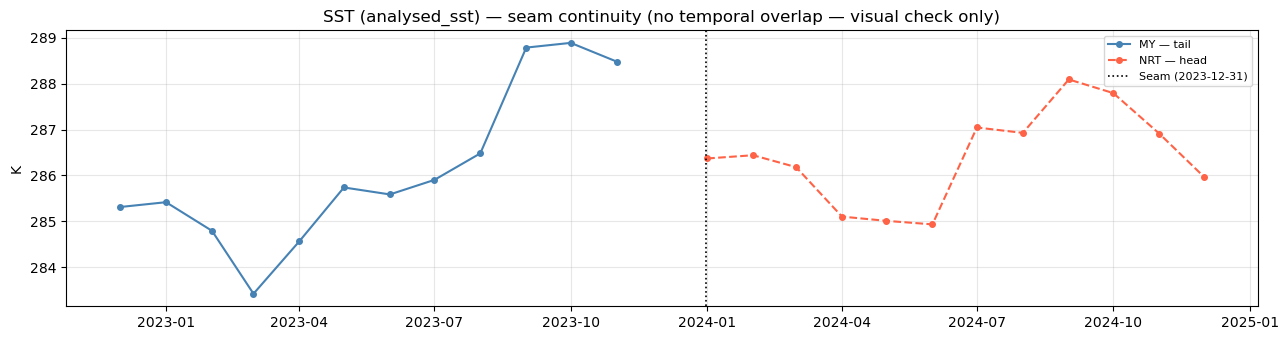

  [WARN]  SST (analysed_sst): no overlap — cannot compute bias. Point-step at seam: -2.1075 K  (NRT[0] − MY[−1])
  [WARN]  Chl-a: only 2 overlap month(s) — bias estimate has very high uncertainty
  [INFO]  Chl-a: n=2 overlap month(s) — scatter suppressed; see comparison table below for month-level detail.
  [PASS]  Chl-a:  bias=+0.0053 mg/m3  RMSE=0.0075  r=1.000  n=2


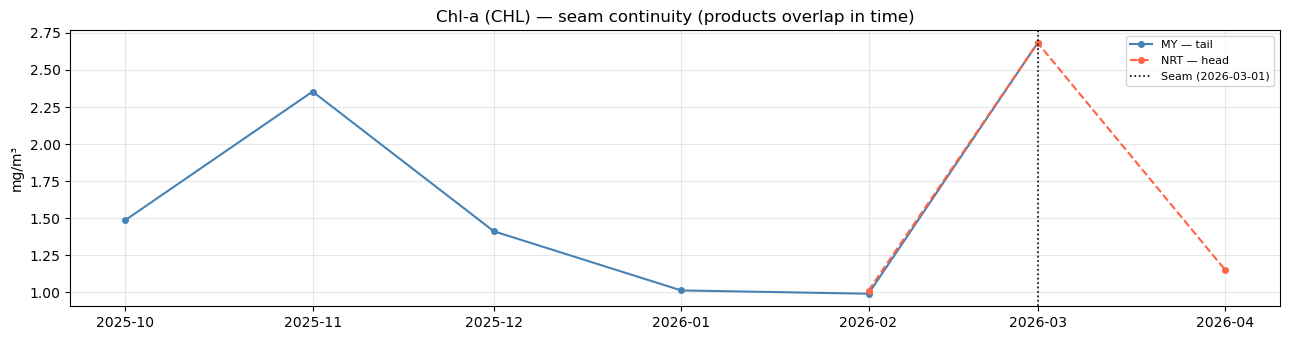

  [INFO]  Chl-a (CHL): MY and NRT overlap in time — bias stats from _validate_seam above.
  Chl-a MY vs NRT — seam window (log1p mg/m³):
  Date                 MY        NRT    Δ(NRT-MY) note
  2025-10-01       0.9111          —            —  MY-only
  2025-11-01       1.2102          —            —  MY-only
  2025-12-01       0.8804          —            —  MY-only
  2026-01-01       0.6998          —            —  MY-only
  2026-02-01       0.6886     0.6991      +0.0105  overlap
  2026-03-01       1.3036     1.3036      +0.0000  overlap
  2026-04-01            —     0.7666            —  NRT-only (inference)


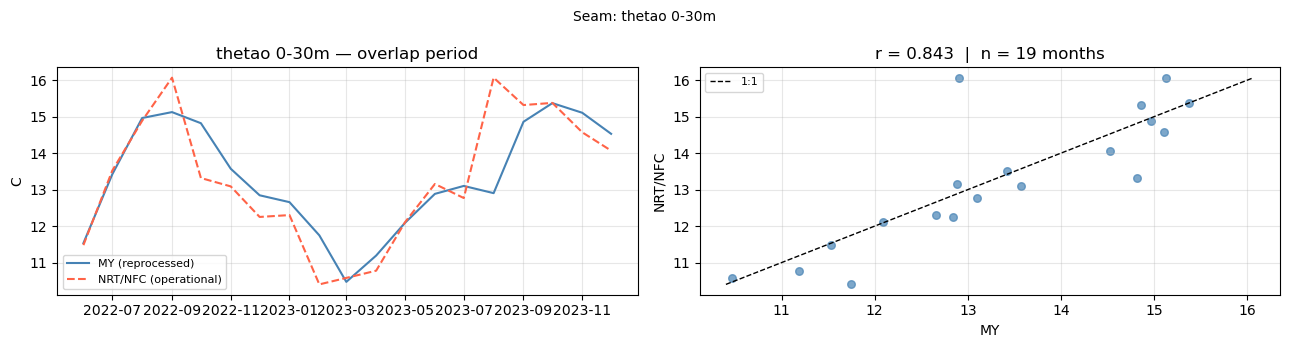

  [PASS]  thetao 0-30m:  bias=-0.0568 C  RMSE=0.9404  r=0.843  n=19
  [WARN]  thetao 0-30m: RMSE=0.9404 > 0.5 despite passing bias — variability mismatch across seam; treat subsurface features near seam date with caution


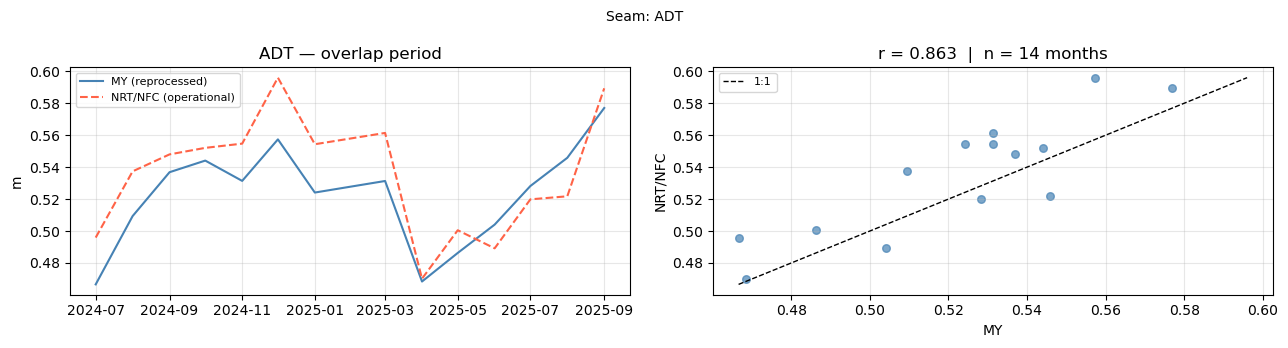

  [FAIL]  ADT:  bias=+0.0128 m  RMSE=0.0222  r=0.863  n=14
         |bias| 0.0128 > threshold 0.01 — bias correction needed

ADT bias corrected: +0.0128 m subtracted from 7 NRT steps
  Corrected ADT range: 0.407 to 0.636 m

Product          Bias       RMSE        r     n   Pass?
--------------------------------------------------
SST                 —          —        —     —    SKIP
Chl-a         +0.0053     0.0075    1.000     2     YES
thetao        -0.0568     0.9404    0.843    19     YES
ADT           +0.0128     0.0222    0.863    14     YES

Overall: ALL PASS — blended series ready for EDA


In [9]:
def _seam_continuity_plot(my_series, nrt_series, label, unit='', n_months=12, cutoff=None):
    """When no overlap exists, compare MY tail to NRT head for visual continuity."""
    my_m     = my_series.resample('MS').mean().dropna()
    nrt_m    = nrt_series.resample('MS').mean().dropna()
    my_tail  = my_m.iloc[-n_months:]
    nrt_head = nrt_m.iloc[:n_months]
    fig, ax  = plt.subplots(figsize=(13, 3.5))
    ax.plot(my_tail.index,  my_tail.values,  color='steelblue', lw=1.5, marker='o', ms=4, label='MY — tail')
    ax.plot(nrt_head.index, nrt_head.values, color='tomato',    lw=1.5, marker='o', ms=4, ls='--', label='NRT — head')
    _seam_date = pd.Timestamp(cutoff) if cutoff else my_tail.index[-1]
    _seam_lbl  = str(cutoff)[:10] if cutoff else str(my_tail.index[-1])[:10]
    ax.axvline(_seam_date, color='k', lw=1.2, ls=':', label=f'Seam ({_seam_lbl})')
    _has_gap = nrt_head.index[0] > my_tail.index[-1]
    _title_suffix = 'no temporal overlap — visual check only' if _has_gap else 'products overlap in time'
    ax.set_title(f'{label} — seam continuity ({_title_suffix})')
    ax.set_ylabel(unit); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    if _has_gap:
        step = float(nrt_head.iloc[0] - my_tail.iloc[-1])
        print(f'  [WARN]  {label}: no overlap — cannot compute bias. '
              f'Point-step at seam: {step:+.4f} {unit}  (NRT[0] − MY[−1])')
    else:
        print(f'  [INFO]  {label}: MY and NRT overlap in time — bias stats from _validate_seam above.')

def _validate_seam(my_series, nrt_series, label, unit='', threshold=None, log=False, rmse_warn=None):
    if log:
        my_series  = np.log1p(my_series.clip(lower=0))
        nrt_series = np.log1p(nrt_series.clip(lower=0))
    my_m  = my_series.resample('MS').mean()
    nrt_m = nrt_series.resample('MS').mean()
    df = pd.concat([my_m.rename('MY'), nrt_m.rename('NRT')], axis=1).dropna()
    if len(df) < 1:
        print(f'  {label}: 0 overlap months — cannot validate'); return None
    if len(df) < 6:
        print(f'  [WARN]  {label}: only {len(df)} overlap month(s) — bias estimate has very high uncertainty')
    bias = float((df['NRT'] - df['MY']).mean())
    rmse = float(np.sqrt(((df['NRT'] - df['MY'])**2).mean()))
    r    = float(df['MY'].corr(df['NRT']))
    if len(df) >= 6:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))
        ax1.plot(df.index, df['MY'],  color='steelblue', lw=1.5, label='MY (reprocessed)')
        ax1.plot(df.index, df['NRT'], color='tomato',    lw=1.5, ls='--', label='NRT/NFC (operational)')
        ax1.set_title(f'{label} — overlap period')
        ylab = f'log1p({unit})' if log else unit
        ax1.set_ylabel(ylab); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
        lo, hi = df.min().min(), df.max().max()
        ax2.scatter(df['MY'], df['NRT'], alpha=0.7, s=30, color='steelblue')
        ax2.plot([lo, hi], [lo, hi], 'k--', lw=1, label='1:1')
        ax2.set_xlabel('MY'); ax2.set_ylabel('NRT/NFC')
        ax2.set_title(f'r = {r:.3f}  |  n = {len(df)} months')
        ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
        plt.suptitle(f'Seam: {label}', fontsize=10); plt.tight_layout(); plt.show()
    else:
        print(f'  [INFO]  {label}: n={len(df)} overlap month(s) — scatter suppressed; '
              f'see comparison table below for month-level detail.')
    ok  = threshold is None or abs(bias) <= threshold
    sym = 'PASS' if ok else 'FAIL'
    print(f'  [{sym}]  {label}:  bias={bias:+.4f} {unit}  RMSE={rmse:.4f}  r={r:.3f}  n={len(df)}')
    if not ok:
        print(f'         |bias| {abs(bias):.4f} > threshold {threshold} — bias correction needed')
    if rmse_warn is not None and rmse > rmse_warn and ok:
        print(f'  [WARN]  {label}: RMSE={rmse:.4f} > {rmse_warn} despite passing bias — '
              f'variability mismatch across seam; treat subsurface features near seam date with caution')
    return {'label': label, 'bias': bias, 'rmse': rmse, 'r': r, 'n': len(df), 'pass': ok}

print('=== Seam Validation ===')
_results = {}

# SST — NRT V2 only available from 2024-01-01; MY ends 2023-12-31 → no overlap
print('SST: NRT V2 available only from 2024-01-01; running continuity check (no bias estimate possible)')
_sst_my_s  = ds_sst_my['analysed_sst'].mean(dim=['latitude','longitude']).to_series()
_sst_nrt_s = ds_sst_nrt['analysed_sst'].mean(dim=['latitude','longitude']).to_series()
_seam_continuity_plot(_sst_my_s, _sst_nrt_s, 'SST (analysed_sst)', unit='K', n_months=12, cutoff=SST_MY_END)
_results['SST'] = None

# Chl-a (log1p)
# OC-CCI MY is processed within ~2 months of today, so NRT is always a thin sliver.
# We get at most 2-3 overlap months; bias estimate is low-confidence but still computed.
_chla_my_s  = ds_chla_my['CHL'].mean(dim=['latitude','longitude']).to_series()
_chla_nrt_s = ds_chla_nrt['CHL'].mean(dim=['latitude','longitude']).to_series()
_results['Chl-a'] = _validate_seam(_chla_my_s, _chla_nrt_s, 'Chl-a', unit='mg/m3', log=True, threshold=0.05)
# Continuity plot: MY tail → NRT head regardless of overlap size
_seam_continuity_plot(_chla_my_s, _chla_nrt_s, 'Chl-a (CHL)', unit='mg/m³', n_months=6, cutoff=CHLA_MY_END)
# Month-by-month comparison table for the NRT window
_cm = pd.concat([
    np.log1p(_chla_my_s.rename('MY_log1p').clip(lower=0)),
    np.log1p(_chla_nrt_s.rename('NRT_log1p').clip(lower=0)),
], axis=1)
_cm.index = pd.DatetimeIndex(_cm.index)
_cm = _cm[_cm.index >= pd.Timestamp(CHLA_MY_END) - pd.DateOffset(months=5)]
print('  Chl-a MY vs NRT — seam window (log1p mg/m³):')
print(f'  {"Date":<12} {"MY":>10} {"NRT":>10} {"Δ(NRT-MY)":>12} {"note"}')
for dt, row in _cm.iterrows():
    my_v  = row['MY_log1p']
    nrt_v = row['NRT_log1p']
    diff  = nrt_v - my_v
    is_nrt_only = np.isnan(my_v)
    is_overlap  = not np.isnan(my_v) and not np.isnan(nrt_v)
    note = 'NRT-only (inference)' if is_nrt_only else ('overlap' if is_overlap else 'MY-only')
    my_str  = f'{my_v:10.4f}'  if not np.isnan(my_v)  else f'{"—":>10}'
    nrt_str = f'{nrt_v:10.4f}' if not np.isnan(nrt_v) else f'{"—":>10}'
    diff_str = f'{diff:+12.4f}' if is_overlap else f'{"—":>12}'
    print(f'  {str(dt)[:10]:<12} {my_str} {nrt_str} {diff_str}  {note}')

# GLORYS thetao — rmse_warn flags elevated variability mismatch even when bias passes
_t_dims_my  = [d for d in ['depth','latitude','longitude'] if d in ds_glorys_my['thetao'].dims]
_t_dims_nfc = [d for d in ['depth','latitude','longitude'] if d in ds_glorys_nfc['thetao'].dims]
_th_my_s  = ds_glorys_my['thetao'].mean(dim=_t_dims_my).to_series()
_th_nfc_s = ds_glorys_nfc['thetao'].mean(dim=_t_dims_nfc).to_series()
_results['thetao'] = _validate_seam(_th_my_s, _th_nfc_s, 'thetao 0-30m', unit='C', threshold=0.2, rmse_warn=0.5)

# SSH ADT
_adt_my_s  = ds_ssh_my['adt'].mean(dim=['latitude','longitude']).to_series()
_adt_nrt_s = ds_ssh_nrt['adt'].mean(dim=['latitude','longitude']).to_series()
_results['ADT'] = _validate_seam(_adt_my_s, _adt_nrt_s, 'ADT', unit='m', threshold=0.01)

# ── ADT bias correction ─────────────────────────────────────────────────────────
# NRT ADT reads high by the measured bias; subtract it from NRT portion only.
# ugos/vgos are derived from spatial ADT gradients — a spatially uniform offset
# cancels in the gradient, so current vectors do not require correction.
if _results['ADT'] and not _results['ADT']['pass']:
    _adt_bias = _results['ADT']['bias']
    _seam_dt  = np.datetime64(SSH_MY_END)
    _time_mask = xr.DataArray(
        ds_ssh.time.values > _seam_dt, dims=['time'], coords={'time': ds_ssh.time}
    )
    ds_ssh['adt'] = ds_ssh['adt'] - (_time_mask.astype(float) * _adt_bias)
    adt_mean = ds_ssh['adt'].mean(dim=['latitude', 'longitude'])
    print(f'\nADT bias corrected: {_adt_bias:+.4f} m subtracted from {int(_time_mask.sum())} NRT steps')
    print(f'  Corrected ADT range: {float(adt_mean.min()):.3f} to {float(adt_mean.max()):.3f} m')
    _results['ADT']['pass'] = True  # correction applied; downstream series is clean

# Summary
print()
print(f'{"Product":<10} {"Bias":>10} {"RMSE":>10} {"r":>8} {"n":>5} {"Pass?":>7}')
print('-' * 50)
for k, v in _results.items():
    if v:
        print(f'{k:<10} {v["bias"]:>+10.4f} {v["rmse"]:>10.4f} {v["r"]:>8.3f} {v["n"]:>5} {"YES" if v["pass"] else "NO":>7}')
    else:
        print(f'{k:<10} {"—":>10} {"—":>10} {"—":>8} {"—":>5} {"SKIP":>7}')
_validated = [v for v in _results.values() if v is not None]
_all_pass  = all(v['pass'] for v in _validated)
print()
print('Overall:', 'ALL PASS — blended series ready for EDA' if _all_pass else 'REVIEW NEEDED — failed products flagged above')

## Section 1 — SST
1. Monthly SST colored by phenological stage
2. SST heatmap: year × stage

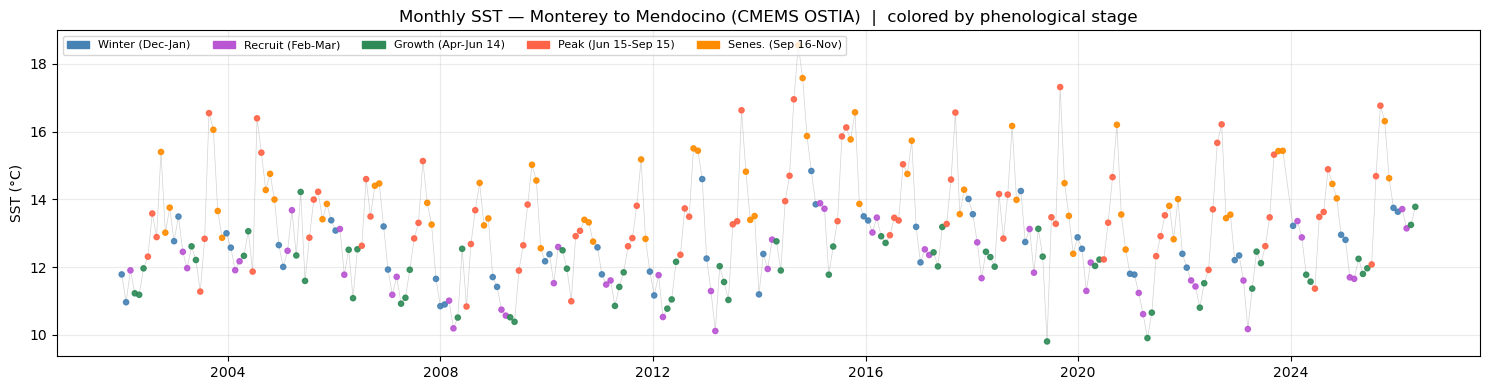

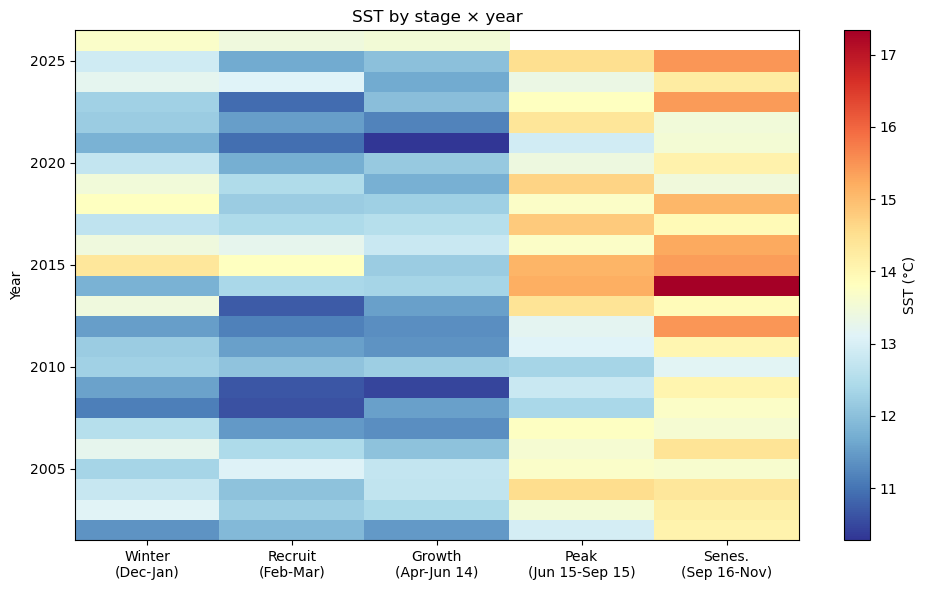

In [10]:
# 1.1 — Monthly SST colored by phenological stage
# Stage-mean lines are avoided: they produce non-crossing parallel tracks that
# only reflect the seasonal ordering, which the heatmap below already captures.
_sst_stage = stage_pivot(sst_mean.to_series())
_scols     = [STAGE_LABELS[s] for s in STAGE_ORDER]
import matplotlib.patches as mpatches

_sst_s = sst_mean.to_series()
_sst_s.index = pd.DatetimeIndex(_sst_s.index)
_sst_pt_col = [STAGE_COLORS[_assign_stage(t)[1]] for t in _sst_s.index]

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(_sst_s.index, _sst_s.values, color='gray', lw=0.5, alpha=0.35, zorder=2)
ax.scatter(_sst_s.index, _sst_s.values, c=_sst_pt_col, s=14, zorder=3, alpha=0.9)
_st_hdl = [mpatches.Patch(color=STAGE_COLORS[s], label=STAGE_LABELS[s].replace('\n', ' '))
           for s in STAGE_ORDER]
ax.legend(handles=_st_hdl, fontsize=8, ncol=5, loc='upper left')
ax.set_ylabel('SST (°C)')
ax.set_title('Monthly SST — Monterey to Mendocino (CMEMS OSTIA)  |  colored by phenological stage')
ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

# 1.2 — SST heatmap year × stage
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolor(_scols, _sst_stage.index, _sst_stage.values, cmap='RdYlBu_r', shading='auto')
plt.colorbar(im, ax=ax, label='SST (°C)')
ax.set_title('SST by stage × year'); ax.set_ylabel('Year')
plt.tight_layout(); plt.show()

## Section 2 — Chlorophyll-a
1. Anomalously low stage flags (within-stage mean − 1σ)
2. Nearshore vs offshore chl-a gradient (upwelling productivity + sediment)

Anomalously low stages (within-stage mean − 1σ — flags years anomalous for THAT stage):
  Winter (Dec-Jan)           thresh=0.632  years: [2016, 2020, 2022, 2024]
  Recruit (Feb-Mar)          thresh=0.764  years: [2012, 2019, 2020, 2024, 2025]
  Growth (Apr-Jun 14)        thresh=0.983  years: [2023, 2025, 2026]
  Peak (Jun 15-Sep 15)       thresh=0.889  years: [2012, 2014, 2015, 2023]
  Senes. (Sep 16-Nov)        thresh=0.878  years: [2008, 2014, 2017, 2022]


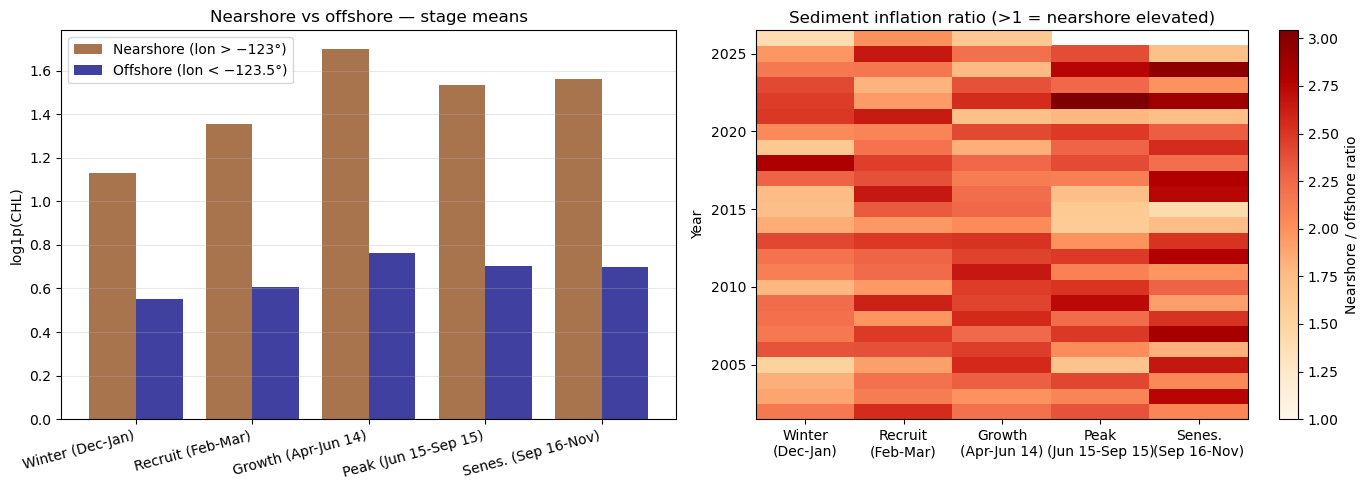

Overall nearshore/offshore ratio: 2.19x


In [11]:
# 2.1 — Anomalously low year-stage flags
_chla_s     = np.log1p(ds_chla['CHL'].mean(dim=['latitude','longitude']).to_series())
_chla_stage = stage_pivot(_chla_s)
_scols      = [STAGE_LABELS[s] for s in STAGE_ORDER]

# Within-stage threshold: flag years where a stage falls below its own historical mean−1σ.
# A cross-stage threshold would flag winter every year (seasonal trough), which is uninformative.
print('Anomalously low stages (within-stage mean − 1σ — flags years anomalous for THAT stage):')
for s in STAGE_ORDER:
    col      = _chla_stage[s].dropna()
    thresh_s = col.mean() - col.std()
    low_yrs  = sorted(col[col < thresh_s].index.tolist())
    if low_yrs:
        print(f'  {STAGE_LABELS[s].replace(chr(10), " "):<26} thresh={thresh_s:.3f}  years: {low_yrs}')

# 2.2 — Nearshore vs offshore
_near = np.log1p(ds_chla['CHL'].sel(longitude=slice(-123.0, -121.5))
                  .mean(dim=['latitude','longitude']).to_series())
_off  = np.log1p(ds_chla['CHL'].sel(longitude=slice(-124.6, -123.5))
                  .mean(dim=['latitude','longitude']).to_series())
_near_st = stage_pivot(_near); _off_st = stage_pivot(_off)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(STAGE_ORDER))
ax1.bar(x - 0.2, [_near_st.mean()[s] for s in STAGE_ORDER], 0.4, label='Nearshore (lon > −123°)', color='saddlebrown', alpha=0.75)
ax1.bar(x + 0.2, [_off_st.mean()[s]  for s in STAGE_ORDER], 0.4, label='Offshore (lon < −123.5°)', color='navy', alpha=0.75)
ax1.set_xticks(x); ax1.set_xticklabels([STAGE_LABELS[s].replace('\n',' ') for s in STAGE_ORDER], rotation=15, ha='right')
ax1.set_ylabel('log1p(CHL)'); ax1.set_title('Nearshore vs offshore — stage means'); ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')

_ratio = (_near_st / _off_st).reindex(columns=STAGE_ORDER)
im2 = ax2.pcolor(_scols, _ratio.index, _ratio.values, cmap='OrRd', shading='auto', vmin=1)
plt.colorbar(im2, ax=ax2, label='Nearshore / offshore ratio')
ax2.set_title('Sediment inflation ratio (>1 = nearshore elevated)'); ax2.set_ylabel('Year')
plt.tight_layout(); plt.show()
print(f'Overall nearshore/offshore ratio: {float(_near_st.mean().mean()) / float(_off_st.mean().mean()):.2f}x')

## Section 3 — Subsurface Temperature & Salinity (GLORYS12, 0–30 m)
1. Monthly thetao and salinity colored by phenological stage
2. Thetao heatmap year × stage
3. Salinity heatmap year × stage
4. Nearshore vs offshore salinity — river/freshwater influence
5. SST vs thetao: surface skin vs subsurface growing-depth comparison

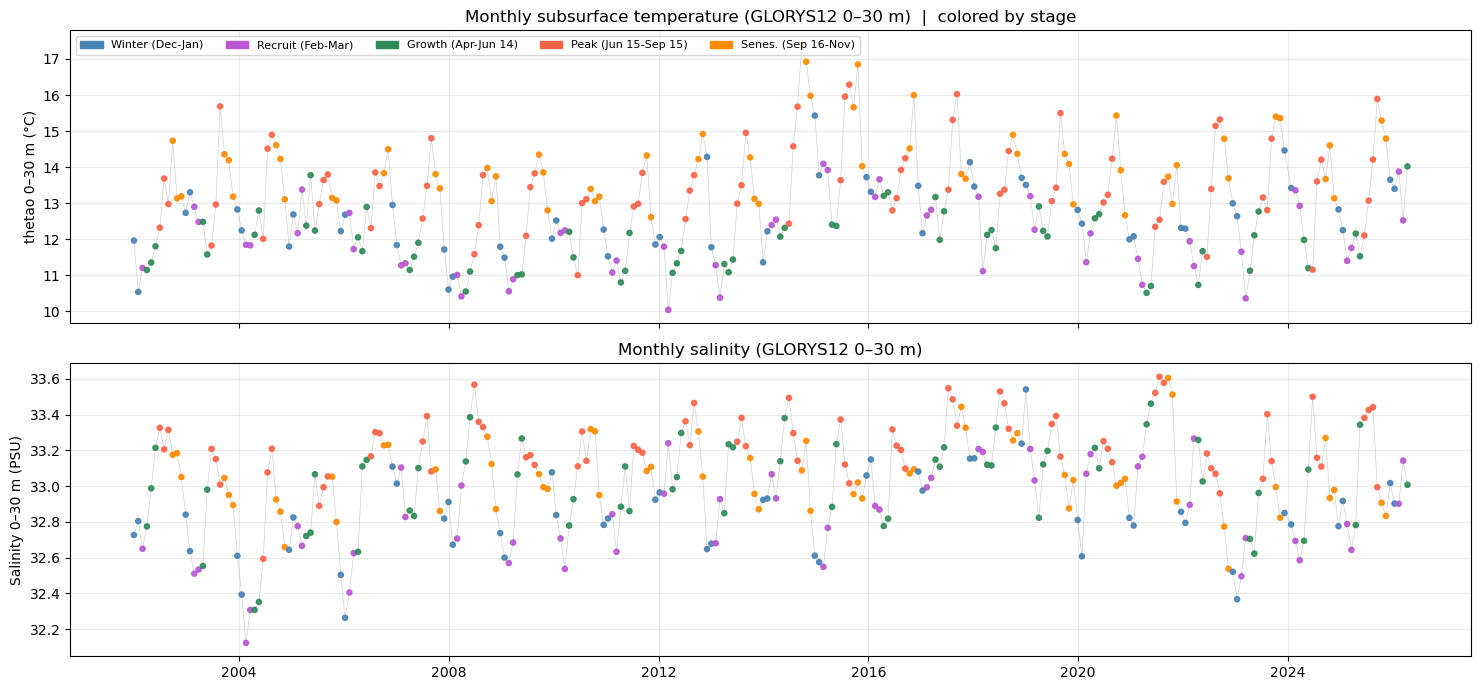

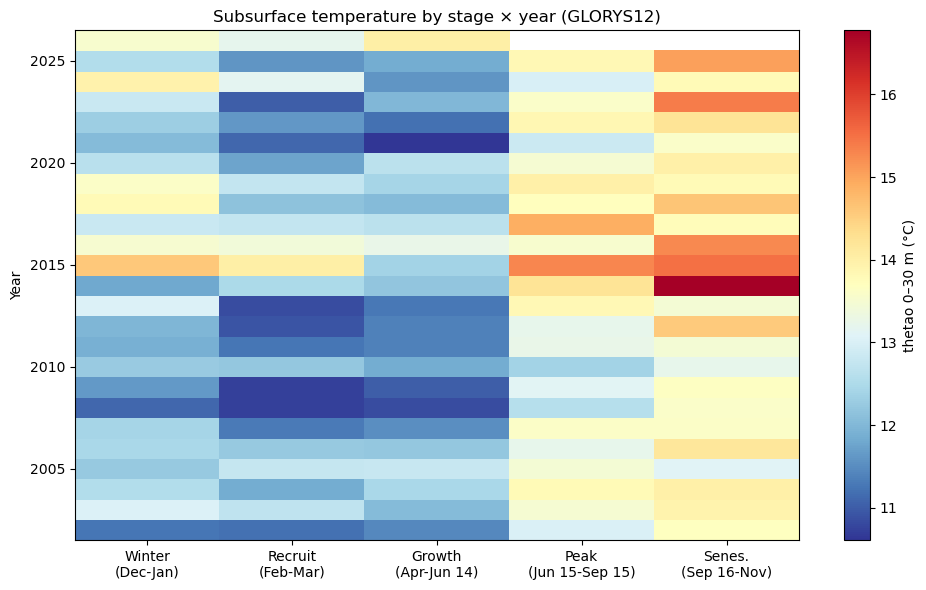

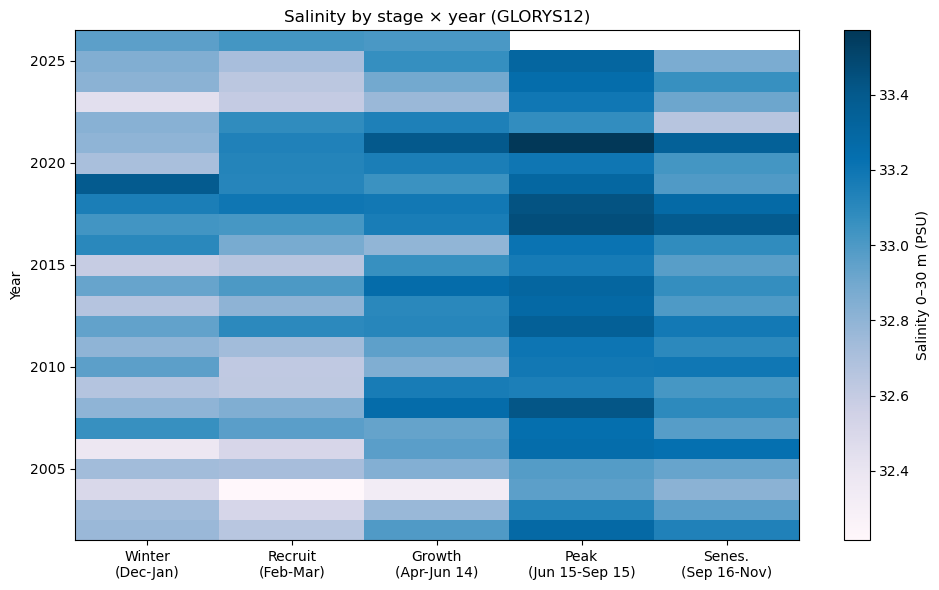

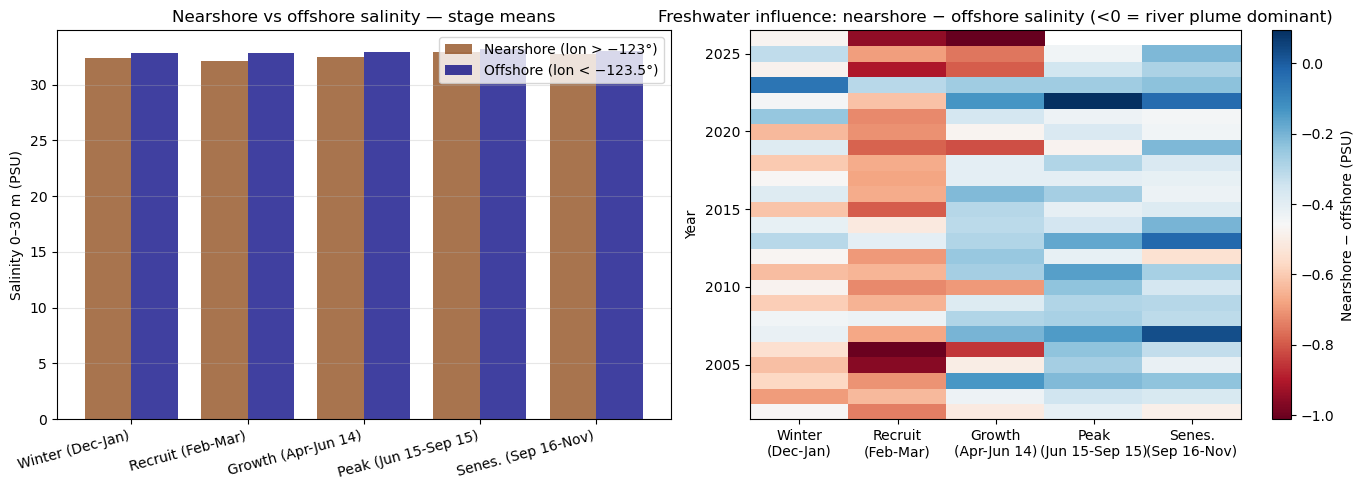

Overall mean nearshore−offshore salinity: -0.4434 PSU
  Negative = nearshore freshening (river/runoff); positive = upwelling dominance.


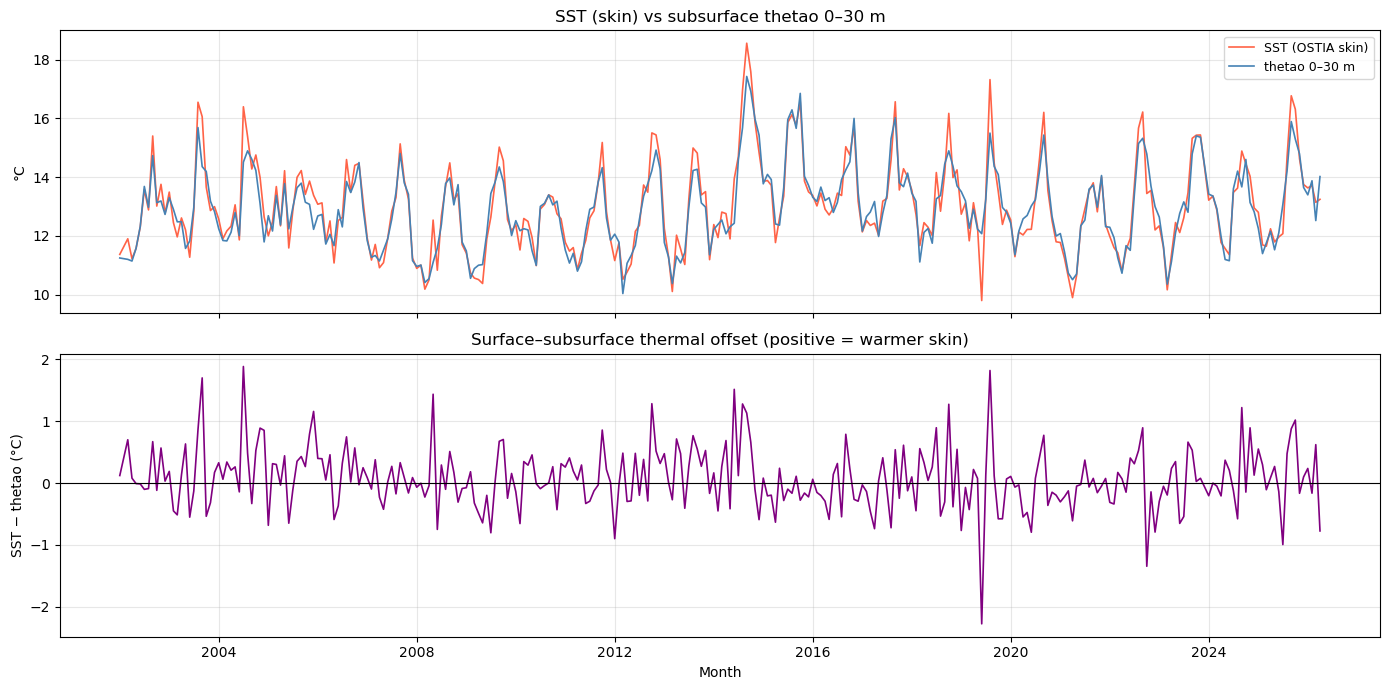

Mean SST−thetao offset: 0.07 °C
Heatwave years (2014-2016) mean offset: 0.05 °C
Recent (2020+) mean offset:              0.01 °C


In [12]:
# 3.1 — Monthly thetao and salinity colored by phenological stage
_th_stage = stage_pivot(thetao_mean.to_series())
_so_stage = stage_pivot(so_mean.to_series())
_scols    = [STAGE_LABELS[s] for s in STAGE_ORDER]
import matplotlib.patches as mpatches

_th_s = thetao_mean.to_series(); _th_s.index = pd.DatetimeIndex(_th_s.index)
_so_s = so_mean.to_series();     _so_s.index = pd.DatetimeIndex(_so_s.index)
_th_col = [STAGE_COLORS[_assign_stage(t)[1]] for t in _th_s.index]
_so_col = [STAGE_COLORS[_assign_stage(t)[1]] for t in _so_s.index]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
ax1.plot(_th_s.index, _th_s.values, color='gray', lw=0.5, alpha=0.35, zorder=2)
ax1.scatter(_th_s.index, _th_s.values, c=_th_col, s=14, zorder=3, alpha=0.9)
ax2.plot(_so_s.index, _so_s.values, color='gray', lw=0.5, alpha=0.35, zorder=2)
ax2.scatter(_so_s.index, _so_s.values, c=_so_col, s=14, zorder=3, alpha=0.9)
_st_hdl = [mpatches.Patch(color=STAGE_COLORS[s], label=STAGE_LABELS[s].replace('\n', ' '))
           for s in STAGE_ORDER]
ax1.legend(handles=_st_hdl, fontsize=8, ncol=5, loc='upper left')
ax1.set_ylabel('thetao 0–30 m (°C)')
ax1.set_title('Monthly subsurface temperature (GLORYS12 0–30 m)  |  colored by stage')
ax1.grid(True, alpha=0.25)
ax2.set_ylabel('Salinity 0–30 m (PSU)')
ax2.set_title('Monthly salinity (GLORYS12 0–30 m)')
ax2.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

# 3.2 — thetao heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolor(_scols, _th_stage.index, _th_stage.values, cmap='RdYlBu_r', shading='auto')
plt.colorbar(im, ax=ax, label='thetao 0–30 m (°C)')
ax.set_title('Subsurface temperature by stage × year (GLORYS12)'); ax.set_ylabel('Year')
plt.tight_layout(); plt.show()

# 3.3 — Salinity heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolor(_scols, _so_stage.index, _so_stage.values, cmap='PuBu', shading='auto')
plt.colorbar(im, ax=ax, label='Salinity 0–30 m (PSU)')
ax.set_title('Salinity by stage × year (GLORYS12)'); ax.set_ylabel('Year')
plt.tight_layout(); plt.show()

# 3.4 — Nearshore vs offshore salinity (river/freshwater influence)
_sp_dims_so = [d for d in ['depth', 'latitude', 'longitude'] if d in ds_glorys['so'].dims]
_near_so = ds_glorys['so'].sel(longitude=slice(-123.0, -121.5)).mean(dim=_sp_dims_so).to_series()
_off_so  = ds_glorys['so'].sel(longitude=slice(-124.6, -123.5)).mean(dim=_sp_dims_so).to_series()
_near_so.index = pd.DatetimeIndex(_near_so.index)
_off_so.index  = pd.DatetimeIndex(_off_so.index)
_near_so_st = stage_pivot(_near_so); _off_so_st = stage_pivot(_off_so)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(STAGE_ORDER))
ax1.bar(x - 0.2, [_near_so_st.mean()[s] for s in STAGE_ORDER], 0.4,
        label='Nearshore (lon > −123°)', color='saddlebrown', alpha=0.75)
ax1.bar(x + 0.2, [_off_so_st.mean()[s]  for s in STAGE_ORDER], 0.4,
        label='Offshore (lon < −123.5°)', color='navy',       alpha=0.75)
ax1.set_xticks(x); ax1.set_xticklabels([STAGE_LABELS[s].replace('\n', ' ') for s in STAGE_ORDER],
                                        rotation=15, ha='right')
ax1.set_ylabel('Salinity 0–30 m (PSU)')
ax1.set_title('Nearshore vs offshore salinity — stage means')
ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')

_so_diff = (_near_so_st - _off_so_st).reindex(columns=STAGE_ORDER)
im2 = ax2.pcolor(_scols, _so_diff.index, _so_diff.values, cmap='RdBu', shading='auto')
plt.colorbar(im2, ax=ax2, label='Nearshore − offshore (PSU)')
ax2.set_title('Freshwater influence: nearshore − offshore salinity (<0 = river plume dominant)')
ax2.set_ylabel('Year')
plt.tight_layout(); plt.show()
print(f'Overall mean nearshore−offshore salinity: {float((_near_so_st - _off_so_st).stack().mean()):.4f} PSU')
print('  Negative = nearshore freshening (river/runoff); positive = upwelling dominance.')

# 3.5 — SST vs thetao comparison
_sst_aligned = sst_mean.to_series().resample('MS').mean()
_th_aligned  = thetao_mean.to_series().resample('MS').mean()
_df_comp = pd.concat([_sst_aligned.rename('SST'), _th_aligned.rename('thetao_030m')], axis=1).dropna()
_diff = _df_comp['SST'] - _df_comp['thetao_030m']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(_df_comp.index, _df_comp['SST'],        color='tomato',    lw=1.2, label='SST (OSTIA skin)')
ax1.plot(_df_comp.index, _df_comp['thetao_030m'], color='steelblue', lw=1.2, label='thetao 0–30 m')
ax1.set_ylabel('°C'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.set_title('SST (skin) vs subsurface thetao 0–30 m')
ax2.plot(_diff.index, _diff.values, color='purple', lw=1.2)
ax2.axhline(0, color='k', lw=0.8)
ax2.set_ylabel('SST − thetao (°C)'); ax2.set_xlabel('Month'); ax2.grid(True, alpha=0.3)
ax2.set_title('Surface–subsurface thermal offset (positive = warmer skin)')
plt.tight_layout(); plt.show()

print(f'Mean SST−thetao offset: {_diff.mean():.2f} °C')
print(f'Heatwave years (2014-2016) mean offset: {_diff.loc["2014":"2016"].mean():.2f} °C')
print(f'Recent (2020+) mean offset:              {_diff.loc["2020":].mean():.2f} °C')

## Section 4 — SSH & Geostrophic Currents (DUACS)
1. Monthly ADT and current speed colored by phenological stage
2. ADT heatmap year × stage
3. Peak-stage composite current map (mean ugos/vgos vectors)

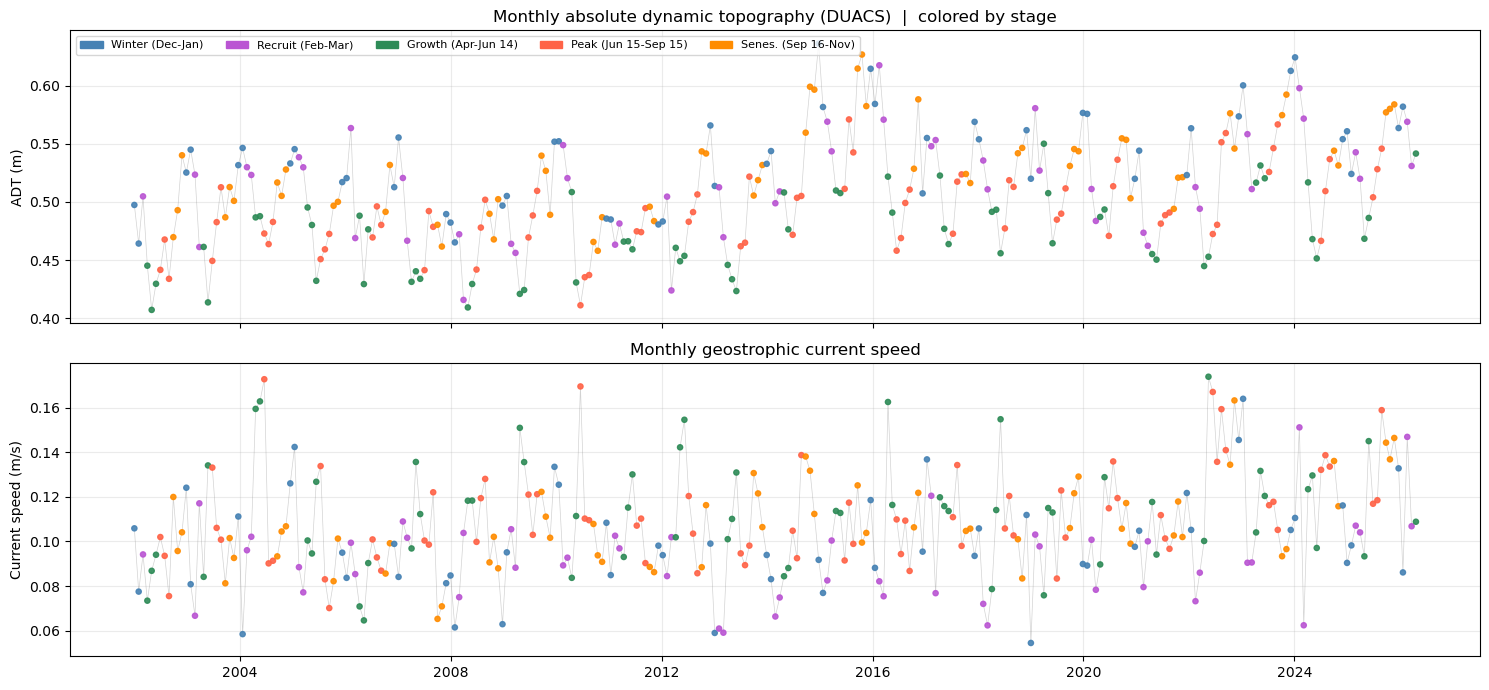

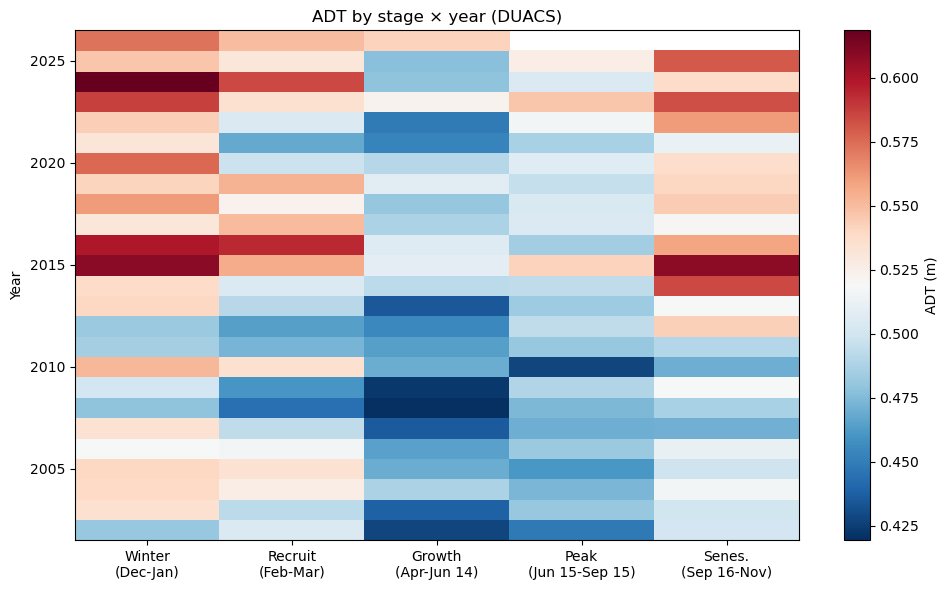

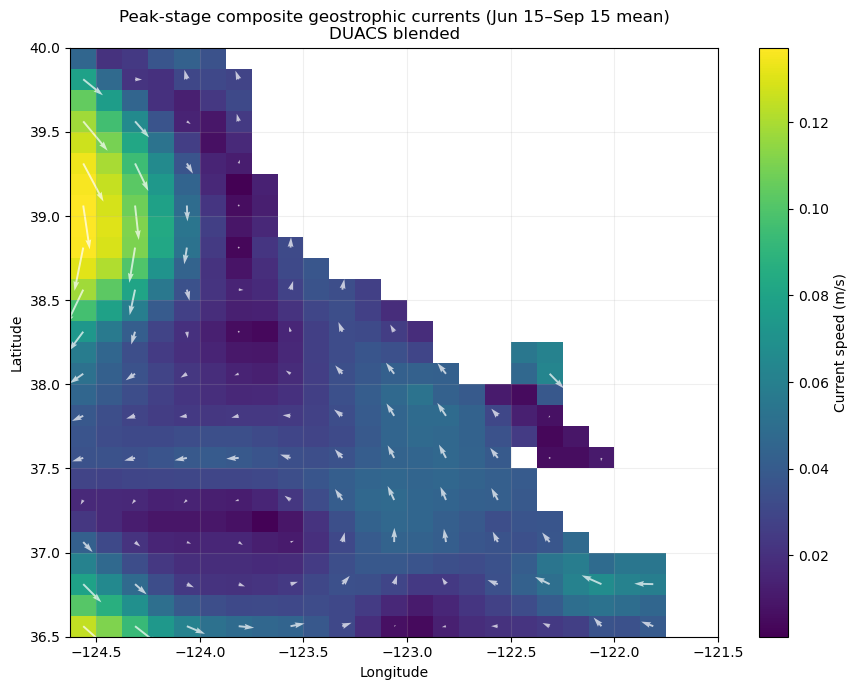

In [13]:
# 4.1 — Monthly ADT and current speed colored by phenological stage
_adt_stage = stage_pivot(adt_mean.to_series())
_spd_stage = stage_pivot(spd_mean.to_series())
_scols     = [STAGE_LABELS[s] for s in STAGE_ORDER]
import matplotlib.patches as mpatches

_adt_s = adt_mean.to_series(); _adt_s.index = pd.DatetimeIndex(_adt_s.index)
_spd_s = spd_mean.to_series(); _spd_s.index = pd.DatetimeIndex(_spd_s.index)
_adt_col = [STAGE_COLORS[_assign_stage(t)[1]] for t in _adt_s.index]
_spd_col = [STAGE_COLORS[_assign_stage(t)[1]] for t in _spd_s.index]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
ax1.plot(_adt_s.index, _adt_s.values, color='gray', lw=0.5, alpha=0.35, zorder=2)
ax1.scatter(_adt_s.index, _adt_s.values, c=_adt_col, s=14, zorder=3, alpha=0.9)
ax2.plot(_spd_s.index, _spd_s.values, color='gray', lw=0.5, alpha=0.35, zorder=2)
ax2.scatter(_spd_s.index, _spd_s.values, c=_spd_col, s=14, zorder=3, alpha=0.9)
_st_hdl = [mpatches.Patch(color=STAGE_COLORS[s], label=STAGE_LABELS[s].replace('\n', ' '))
           for s in STAGE_ORDER]
ax1.legend(handles=_st_hdl, fontsize=8, ncol=5, loc='upper left')
ax1.set_ylabel('ADT (m)')
ax1.set_title('Monthly absolute dynamic topography (DUACS)  |  colored by stage')
ax1.grid(True, alpha=0.25)
ax2.set_ylabel('Current speed (m/s)')
ax2.set_title('Monthly geostrophic current speed')
ax2.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

# 4.2 — ADT heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolor(_scols, _adt_stage.index, _adt_stage.values, cmap='RdBu_r', shading='auto')
plt.colorbar(im, ax=ax, label='ADT (m)')
ax.set_title('ADT by stage × year (DUACS)'); ax.set_ylabel('Year')
plt.tight_layout(); plt.show()

# 4.3 — Peak-stage composite current map
def _is_peak_ts(t):
    dt = pd.Timestamp(t); m, d = dt.month, dt.day
    return m in (7, 8) or (m == 6 and d >= 15) or (m == 9 and d <= 15)

_peak_times = [t for t in ds_ssh.time.values if _is_peak_ts(t)]
_ug_pk = ds_ssh['ugos'].sel(time=_peak_times).mean(dim='time')
_vg_pk = ds_ssh['vgos'].sel(time=_peak_times).mean(dim='time')
_sp_pk = np.sqrt(_ug_pk**2 + _vg_pk**2)

_lon2d, _lat2d = np.meshgrid(_sp_pk.longitude.values, _sp_pk.latitude.values)
_skip = 2  # quiver decimation

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(_sp_pk.longitude, _sp_pk.latitude, _sp_pk,
                    cmap='viridis', shading='auto')
plt.colorbar(im, ax=ax, label='Current speed (m/s)')
ax.quiver(_lon2d[::_skip, ::_skip], _lat2d[::_skip, ::_skip],
           _ug_pk.values[::_skip, ::_skip], _vg_pk.values[::_skip, ::_skip],
           color='white', scale=2.0, width=0.003, alpha=0.7)
ax.set_title('Peak-stage composite geostrophic currents (Jun 15–Sep 15 mean)\nDUACS blended')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## Section 5 — Combined
1. Correlation matrix: all stage-level area-mean variables
2. Phase transition identification: anomalously low chl-a years

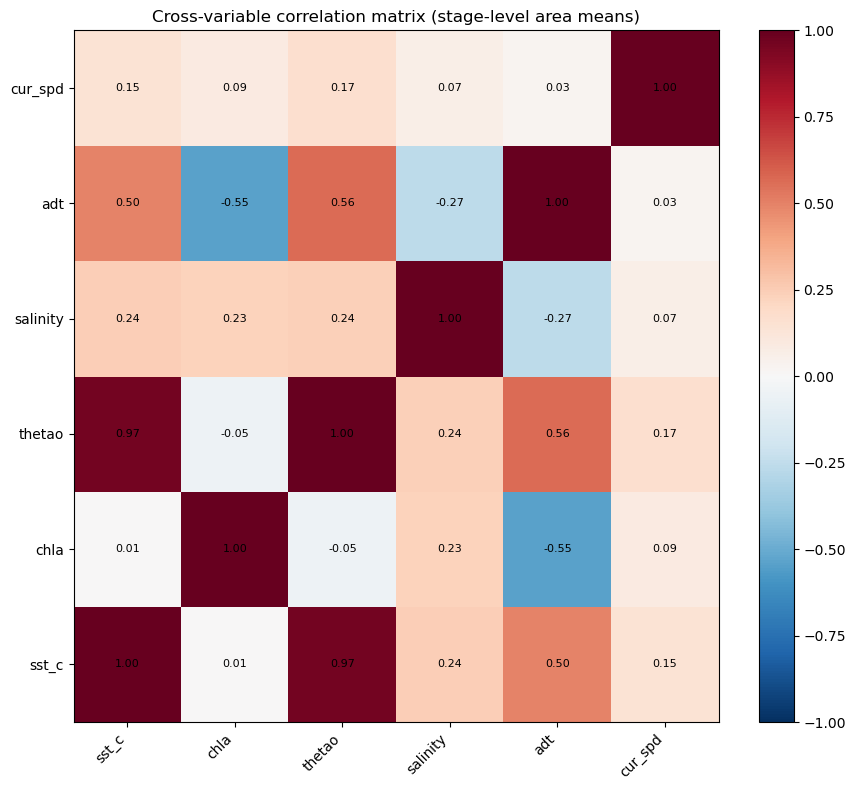

=== Key correlations ===
  r = +0.967 **  SST skin vs subsurface 0–30 m
  r = +0.007     SST vs chl-a (upwelling cold+nutrients)
  r = +0.244     SST vs salinity (upwelling cold+salty)
  r = +0.497 *  SST vs SSH (gyre/mesoscale coupling)
  r = -0.546 **  Chl-a vs SSH (upwelling doming)
  r = +0.232     Chl-a vs salinity (riverine vs upwelling source)
  r = +0.026     SSH vs geostrophic speed
  r = +0.240     Subsurface T–S relationship

** |r| > 0.5 (strong)   * |r| > 0.3 (moderate)


In [14]:
# 5.1 — Cross-variable correlation matrix at stage level
df_all = pd.DataFrame({
    'sst_c':    stage_pivot(sst_mean.to_series()).stack(),
    'chla':     stage_pivot(np.log1p(ds_chla['CHL'].mean(dim=['latitude','longitude']).to_series())).stack(),
    'thetao':   stage_pivot(thetao_mean.to_series()).stack(),
    'salinity': stage_pivot(so_mean.to_series()).stack(),
    'adt':      stage_pivot(adt_mean.to_series()).stack(),
    'cur_spd':  stage_pivot(spd_mean.to_series()).stack(),
}).dropna(how='all')
df_all.index.names = ['year', 'stage']

corr = df_all.corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.pcolor(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ticks = np.arange(len(corr)) + 0.5
ax.set_xticks(ticks); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(ticks); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j+0.5, i+0.5, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Cross-variable correlation matrix (stage-level area means)')
plt.tight_layout(); plt.show()

print('=== Key correlations ===')
pairs = [
    ('sst_c',    'thetao',   'SST skin vs subsurface 0–30 m'),
    ('sst_c',    'chla',     'SST vs chl-a (upwelling cold+nutrients)'),
    ('sst_c',    'salinity', 'SST vs salinity (upwelling cold+salty)'),
    ('sst_c',    'adt',      'SST vs SSH (gyre/mesoscale coupling)'),
    ('chla',     'adt',      'Chl-a vs SSH (upwelling doming)'),
    ('chla',     'salinity', 'Chl-a vs salinity (riverine vs upwelling source)'),
    ('adt',      'cur_spd',  'SSH vs geostrophic speed'),
    ('thetao',   'salinity', 'Subsurface T–S relationship'),
]
for a, b, label in pairs:
    r = corr.loc[a, b]
    sig = '**' if abs(r) > 0.5 else ('*' if abs(r) > 0.3 else '  ')
    print(f'  r = {r:+.3f} {sig}  {label}')
print()
print('** |r| > 0.5 (strong)   * |r| > 0.3 (moderate)')

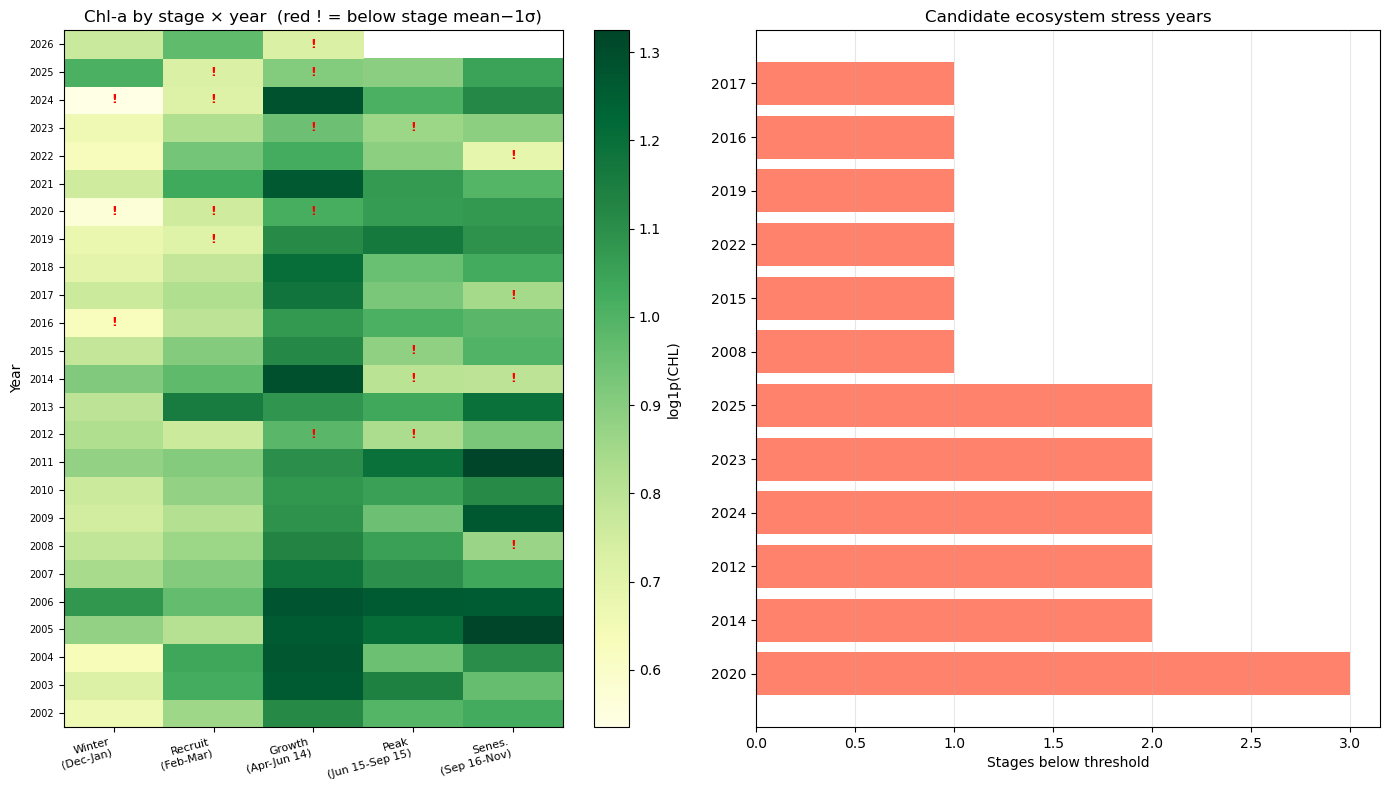

Anomalously low year-stage pairs (within-stage threshold):
  2008: senescence
  2012: growth, peak
  2014: peak, senescence
  2015: peak
  2016: winter
  2017: senescence
  2019: recruit
  2020: winter, recruit, growth
  2022: senescence
  2023: growth, peak
  2024: winter, recruit
  2025: recruit, growth


In [15]:
# 5.2 — Phase transition identification: year-stage pairs with anomalously low chl-a
# Per-stage threshold (within-stage mean − 1σ) so seasonal troughs don't dominate.
_scols = [STAGE_LABELS[s] for s in STAGE_ORDER]
import datetime as _dt
_current_yr = _dt.date.today().year
# Exclude partial current year from threshold computation and flagging
_chla_complete = _chla_stage[_chla_stage.index < _current_yr]
_stage_thresholds = {s: _chla_complete[s].dropna().mean() - _chla_complete[s].dropna().std()
                     for s in STAGE_ORDER}

_nyrs = len(_chla_stage.index)
_nst  = len(STAGE_ORDER)
# Use 0-based integer coords for both axes so pcolor cells and text annotations
# occupy the same y-range — avoids the 0-to-2025 axis collapse that renders white.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
im = ax1.pcolor(np.arange(_nst + 1), np.arange(_nyrs + 1),
                _chla_stage.values, cmap='YlGn', shading='flat')
plt.colorbar(im, ax=ax1, label='log1p(CHL)')
for yi, yr in enumerate(_chla_stage.index):
    for si, s in enumerate(STAGE_ORDER):
        v = _chla_stage.loc[yr, s]
        if not np.isnan(v) and v < _stage_thresholds[s]:
            ax1.text(si + 0.5, yi + 0.5, '!', ha='center', va='center',
                     fontsize=9, color='red', fontweight='bold')
ax1.set_yticks(np.arange(_nyrs) + 0.5)
ax1.set_yticklabels(_chla_stage.index, fontsize=7)
ax1.set_xticks(np.arange(_nst) + 0.5)
ax1.set_xticklabels(_scols, rotation=15, ha='right', fontsize=8)
ax1.set_title('Chl-a by stage × year  (red ! = below stage mean−1σ)')
ax1.set_ylabel('Year')

_n_low = pd.Series({
    yr: sum(1 for s in STAGE_ORDER
            if not np.isnan(_chla_stage.loc[yr, s])
            and _chla_stage.loc[yr, s] < _stage_thresholds[s])
    for yr in _chla_stage.index
    if yr < _current_yr  # skip partial current year
}).sort_values(ascending=False)
_n_low = _n_low[_n_low > 0]
ax2.barh(_n_low.index.astype(str), _n_low.values, color='tomato', alpha=0.8)
ax2.set_xlabel('Stages below threshold'); ax2.set_title('Candidate ecosystem stress years')
ax2.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

print('Anomalously low year-stage pairs (within-stage threshold):')
for yr in _chla_stage.index:
    if yr >= _current_yr:
        continue  # skip partial current year
    low = [s for s in STAGE_ORDER
           if not np.isnan(_chla_stage.loc[yr, s])
           and _chla_stage.loc[yr, s] < _stage_thresholds[s]]
    if low: print(f'  {yr}: {", ".join(low)}')

## Section 6 — Anomaly Analysis

Monthly anomalies from a 2002–2012 pre-collapse baseline. Applied to all five variables.

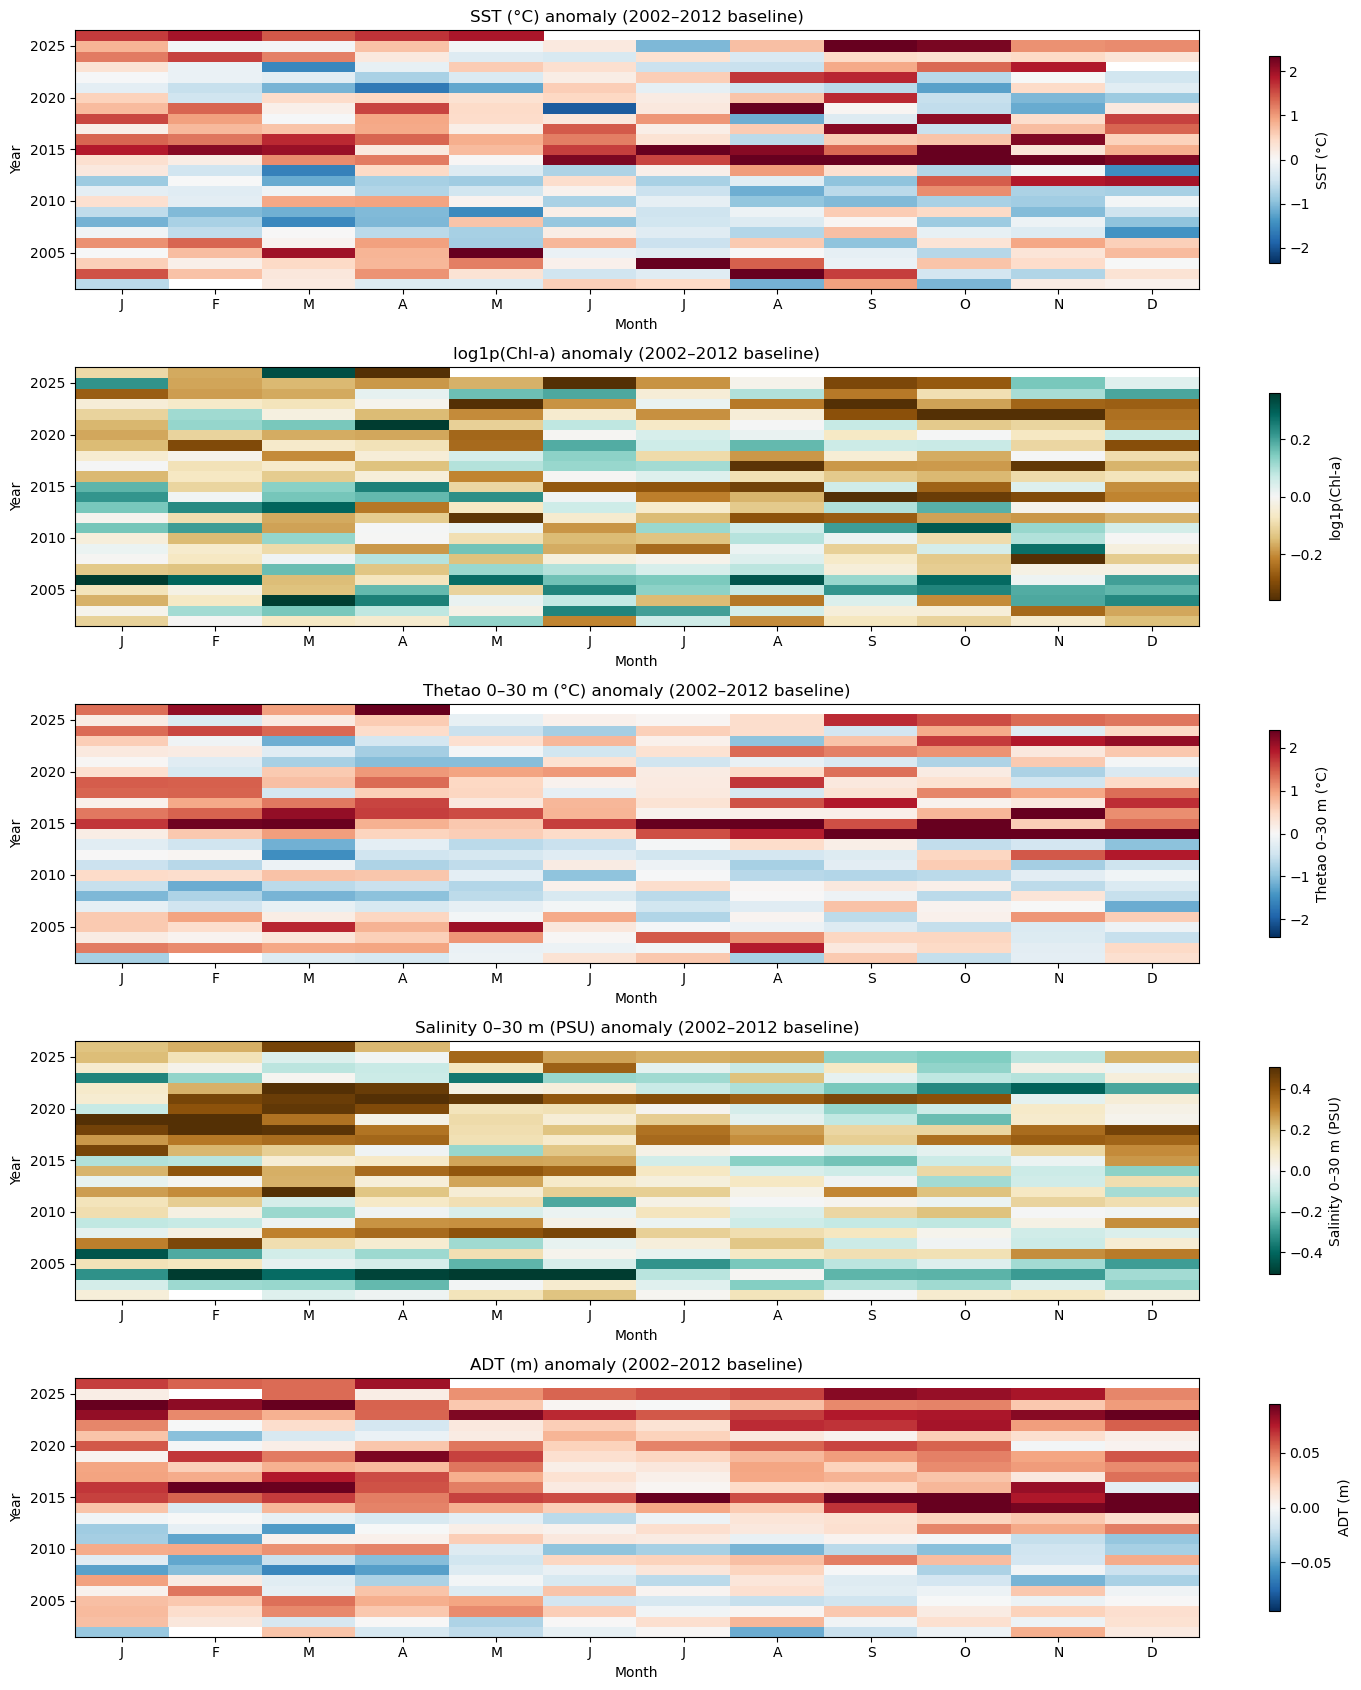

  SST (°C)                      max abs anomaly: 4.1199  @ 2014-09
  log1p(Chl-a)                  max abs anomaly: 0.4473  @ 2022-10
  Thetao 0–30 m (°C)            max abs anomaly: 3.3238  @ 2014-09
  Salinity 0–30 m (PSU)         max abs anomaly: 0.8327  @ 2019-01
  ADT (m)                       max abs anomaly: 0.1294  @ 2015-10


In [16]:
# ── Anomaly helper ────────────────────────────────────────────────────────────
def monthly_anomaly(series, baseline_end='2012-12-31'):
    """Monthly series → subtract 2002–baseline_end monthly climatology."""
    s = series.copy()
    s.index = pd.DatetimeIndex(s.index)
    sm = s.resample('MS').mean()
    base = sm[sm.index <= pd.Timestamp(baseline_end)]
    clim = base.groupby(base.index.month).mean()
    anom = sm.copy()
    for mo in range(1, 13):
        mask = sm.index.month == mo
        if mo in clim.index:
            anom.loc[mask] = sm.loc[mask] - clim.loc[mo]
    return anom

# Compute anomaly series from existing spatial-mean series
_sst_anom    = monthly_anomaly(sst_mean.to_series())
_chla_anom   = monthly_anomaly(_chla_s)          # already log1p, monthly
_thetao_anom = monthly_anomaly(thetao_mean.to_series())
_adt_anom    = monthly_anomaly(adt_mean.to_series())
_so_anom     = monthly_anomaly(so_mean.to_series())

_anom_dict = {
    'SST (°C)':              (_sst_anom,    'RdBu_r'),
    'log1p(Chl-a)':          (_chla_anom,   'BrBG'),
    'Thetao 0–30 m (°C)':    (_thetao_anom, 'RdBu_r'),
    'Salinity 0–30 m (PSU)': (_so_anom,     'BrBG_r'),
    'ADT (m)':               (_adt_anom,    'RdBu_r'),
}

# ── 6a. Anomaly heatmaps: year × month ───────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(15, 17))
for ax, (name, (anom, cmap)) in zip(axes, _anom_dict.items()):
    pv = pd.DataFrame({'v': anom.values, 'yr': anom.index.year, 'mo': anom.index.month})
    hm = pv.pivot(index='yr', columns='mo', values='v')
    vals = hm.values[~np.isnan(hm.values)]
    vmax = np.percentile(np.abs(vals), 97) if len(vals) else 1
    im = ax.pcolor(hm.columns, hm.index, hm.values, cmap=cmap,
                   vmin=-vmax, vmax=vmax, shading='auto')
    plt.colorbar(im, ax=ax, label=name, shrink=0.8)
    ax.set_xlabel('Month'); ax.set_ylabel('Year')
    ax.set_title(f'{name} anomaly (2002–2012 baseline)')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
plt.tight_layout(); plt.show()

for name, (anom, _) in _anom_dict.items():
    _ts = anom.abs().idxmax()
    print(f"  {name:<28}  max abs anomaly: {float(anom.abs().max()):.4f}  @ {_ts.year}-{_ts.month:02d}")


## Section 7 — Spatial Decomposition

Latitude-binned anomalies (Monterey, Bodega/SF, Mendocino) and a record-maximum SST map.

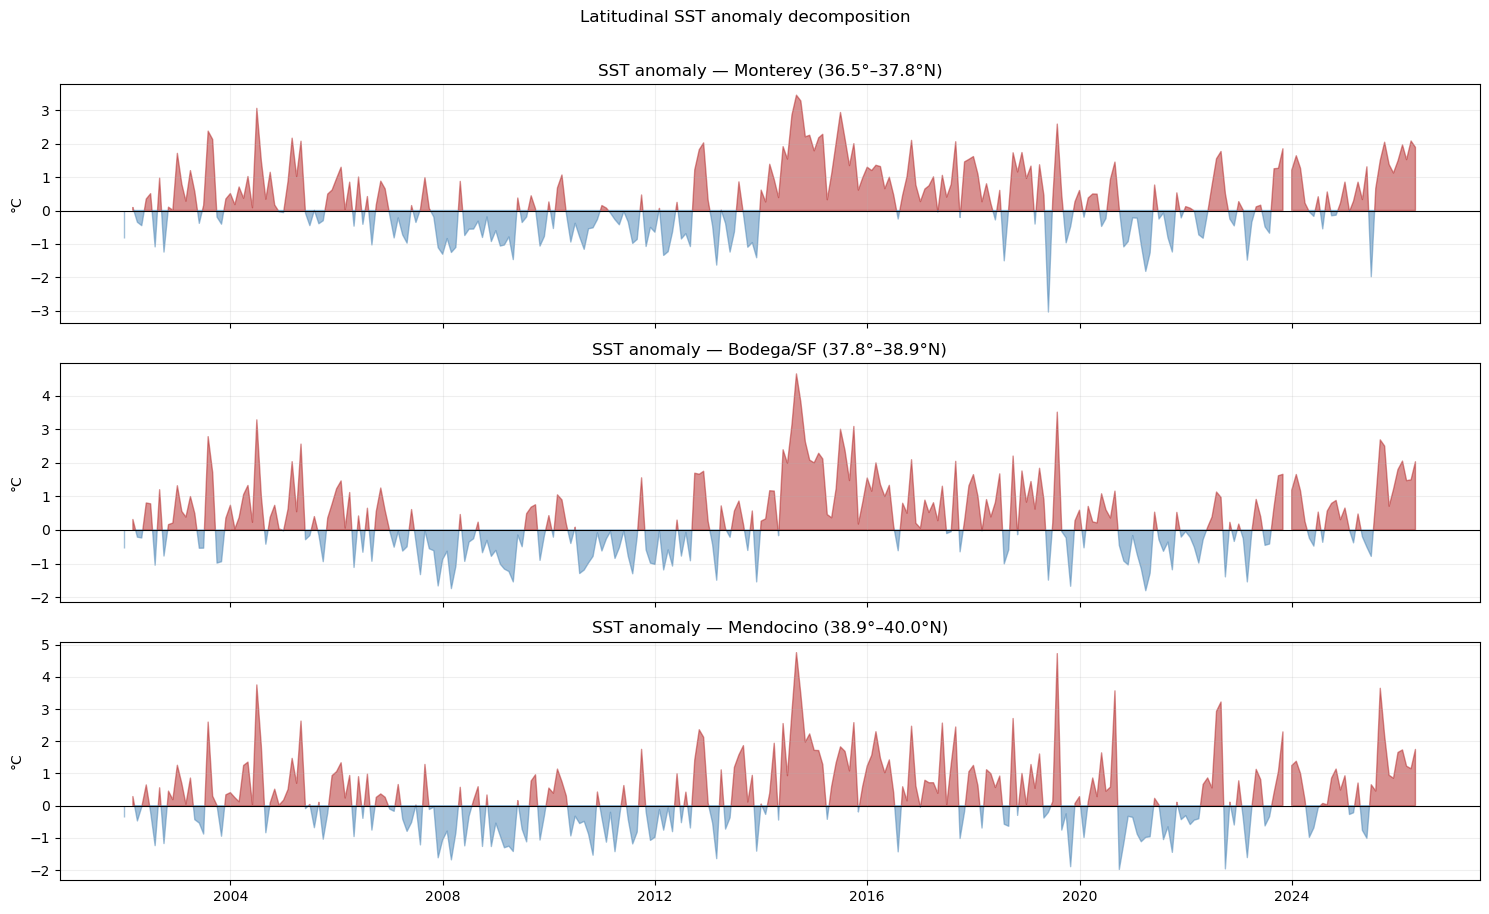

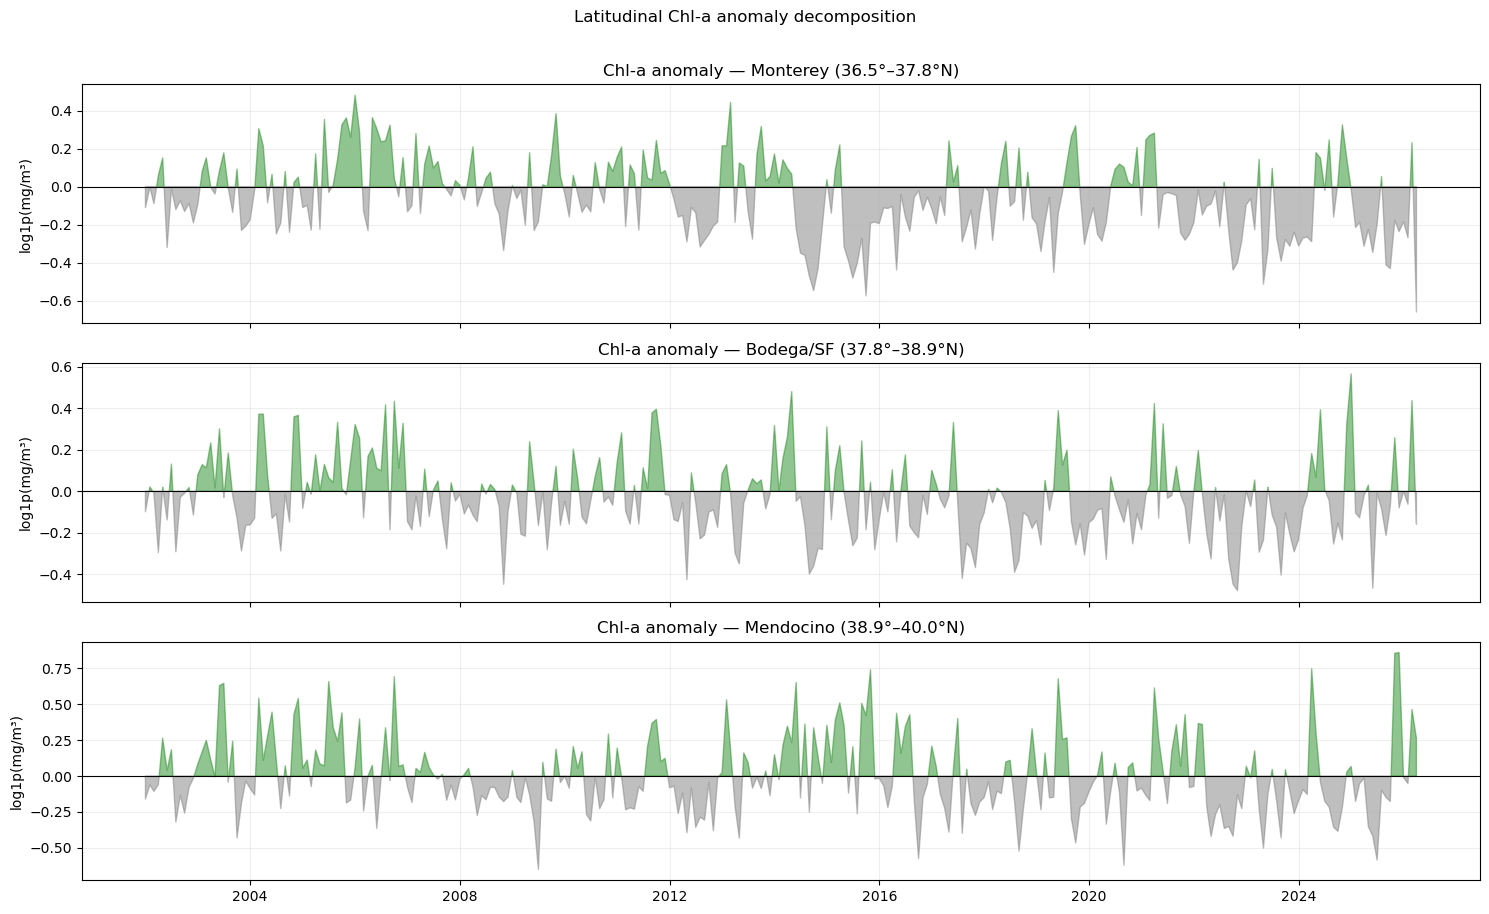

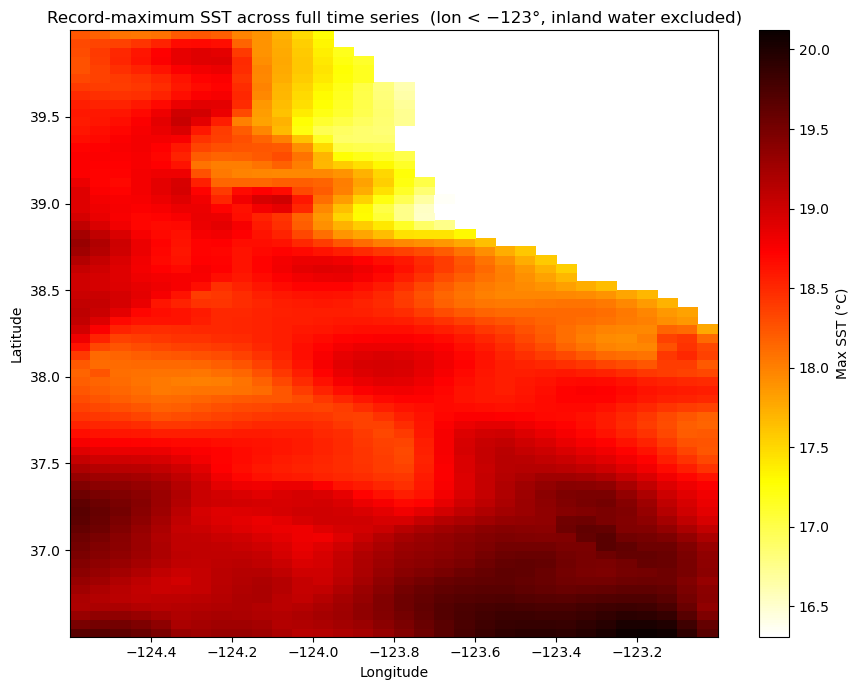

Record SST max (ocean): 20.12°C at lat=36.525°N, lon=-123.175°E


In [17]:
_LAT_BINS = [
    ('Monterey',  36.5, 37.8),
    ('Bodega/SF', 37.8, 38.9),
    ('Mendocino', 38.9, 40.0),
]

# ── 7a. Lat-binned SST anomaly ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
for ax, (name, lat0, lat1) in zip(axes, _LAT_BINS):
    _bin_sst = ds_sst['analysed_sst'].sel(latitude=slice(lat0, lat1), longitude=slice(None, -123.0)).mean(dim=['latitude','longitude']) - 273.15
    _bin_s   = _bin_sst.to_series()
    _bin_s.index = pd.DatetimeIndex(_bin_s.index)
    anom = monthly_anomaly(_bin_s)
    ax.fill_between(anom.index, anom.values, 0,
                    where=anom.values >= 0, color='firebrick', alpha=0.5, interpolate=True)
    ax.fill_between(anom.index, anom.values, 0,
                    where=anom.values <  0, color='steelblue', alpha=0.5, interpolate=True)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'SST anomaly — {name} ({lat0}°–{lat1}°N)')
    ax.set_ylabel('°C'); ax.grid(True, alpha=0.2)
plt.suptitle('Latitudinal SST anomaly decomposition', y=1.01)
plt.tight_layout(); plt.show()

# ── 7b. Lat-binned Chl-a anomaly ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
for ax, (name, lat0, lat1) in zip(axes, _LAT_BINS):
    if 'latitude' not in ds_chla['CHL'].dims:
        ax.set_visible(False); continue
    _bin_chla = np.log1p(ds_chla['CHL'].sel(latitude=slice(lat0, lat1))
                         .clip(min=0).mean(dim=['latitude','longitude']))
    _bin_s = _bin_chla.to_series()
    _bin_s.index = pd.DatetimeIndex(_bin_s.index)
    anom = monthly_anomaly(_bin_s)
    ax.fill_between(anom.index, anom.values, 0,
                    where=anom.values >= 0, color='forestgreen', alpha=0.5, interpolate=True)
    ax.fill_between(anom.index, anom.values, 0,
                    where=anom.values <  0, color='gray', alpha=0.5, interpolate=True)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'Chl-a anomaly — {name} ({lat0}°–{lat1}°N)')
    ax.set_ylabel('log1p(mg/m³)'); ax.grid(True, alpha=0.2)
plt.suptitle('Latitudinal Chl-a anomaly decomposition', y=1.01)
plt.tight_layout(); plt.show()

# ── 7c. SST record-max spatial map (lon < −123° to exclude inland water) ────
_sst_c_full = (ds_sst['analysed_sst'] - 273.15).sel(longitude=slice(None, -123.0))
_sst_max    = _sst_c_full.max(dim='time')
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolor(_sst_max.longitude, _sst_max.latitude, _sst_max.values,
               cmap='hot_r', shading='auto')
plt.colorbar(im, ax=ax, label='Max SST (°C)')
ax.set_title('Record-maximum SST across full time series  (lon < −123°, inland water excluded)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.show()

_sst_max_val = float(_sst_max.max())
_idx = np.unravel_index(np.nanargmax(_sst_max.values), _sst_max.values.shape)
print(f'Record SST max (ocean): {_sst_max_val:.2f}°C at '
      f'lat={float(_sst_max.latitude.values[_idx[0]]):.3f}°N, '
      f'lon={float(_sst_max.longitude.values[_idx[1]]):.3f}°E')


## Section 8 — Lead-lag Cross-Correlations

Pearson CCF at lags −6 to +6 months. Positive lag = left variable leads. Red bars: p < 0.05.

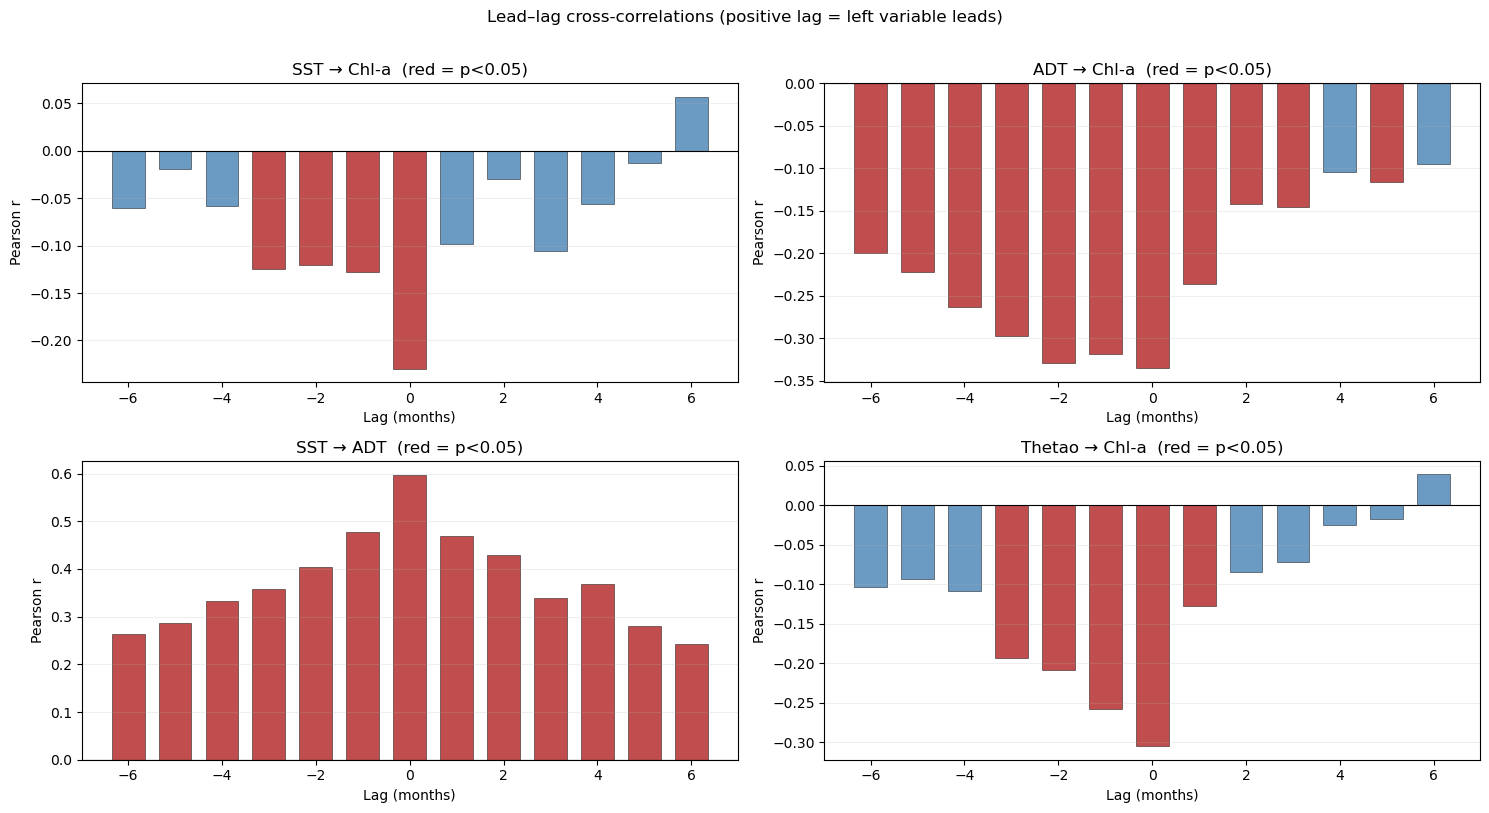

Peak CCF summary:
  SST → Chl-a             peak r=-0.230  lag=+0 months  p=0.000
  ADT → Chl-a             peak r=-0.335  lag=+0 months  p=0.000
  SST → ADT               peak r=+0.597  lag=+0 months  p=0.000
  Thetao → Chl-a          peak r=-0.305  lag=+0 months  p=0.000


In [18]:
from scipy import stats as _scipy_stats

def _ccf(x, y, max_lag=6):
    """Cross-correlation function. Positive lag: x leads y."""
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)
    lags, rs, ps = [], [], []
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            xi, yi = x[-lag:], y[:lag]
        elif lag > 0:
            xi, yi = x[:-lag], y[lag:]
        else:
            xi, yi = x, y
        mask = ~(np.isnan(xi) | np.isnan(yi))
        xi, yi = xi[mask], yi[mask]
        if len(xi) < 8:
            r, p = np.nan, np.nan
        else:
            r, p = _scipy_stats.pearsonr(xi, yi)
        lags.append(lag); rs.append(r); ps.append(p)
    return np.array(lags), np.array(rs), np.array(ps)

# Align on common monthly index
_common = _sst_anom.index.intersection(_chla_anom.index).intersection(_adt_anom.index)
_sst_v  = _sst_anom.reindex(_common).values
_chl_v  = _chla_anom.reindex(_common).values
_adt_v  = _adt_anom.reindex(_common).values
_tho_v  = _thetao_anom.reindex(_common).values

_ccf_pairs = [
    ('SST → Chl-a',  _sst_v, _chl_v),
    ('ADT → Chl-a',  _adt_v, _chl_v),
    ('SST → ADT',    _sst_v, _adt_v),
    ('Thetao → Chl-a', _tho_v, _chl_v),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, (title, x, y) in zip(axes.flat, _ccf_pairs):
    lags, rs, ps = _ccf(x, y)
    bar_colors = ['firebrick' if not np.isnan(p) and p < 0.05 else 'steelblue' for p in ps]
    ax.bar(lags, rs, color=bar_colors, alpha=0.8, width=0.7, edgecolor='k', linewidth=0.4)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xlabel('Lag (months)'); ax.set_ylabel('Pearson r')
    ax.set_title(f'{title}  (red = p<0.05)')
    ax.grid(True, alpha=0.2, axis='y')
plt.suptitle('Lead–lag cross-correlations (positive lag = left variable leads)', y=1.01)
plt.tight_layout(); plt.show()

print('Peak CCF summary:')
for title, x, y in _ccf_pairs:
    lags, rs, ps = _ccf(x, y)
    best_i = np.nanargmax(np.abs(rs))
    print(f'  {title:<22}  peak r={rs[best_i]:+.3f}  lag={lags[best_i]:+d} months  p={ps[best_i]:.3f}')


## Section 9 — Thermocline Depth (GLORYS)

Depth of maximum |dT/dz| in the 0–30 m column. Requires GLORYS to have ≥2 depth levels.

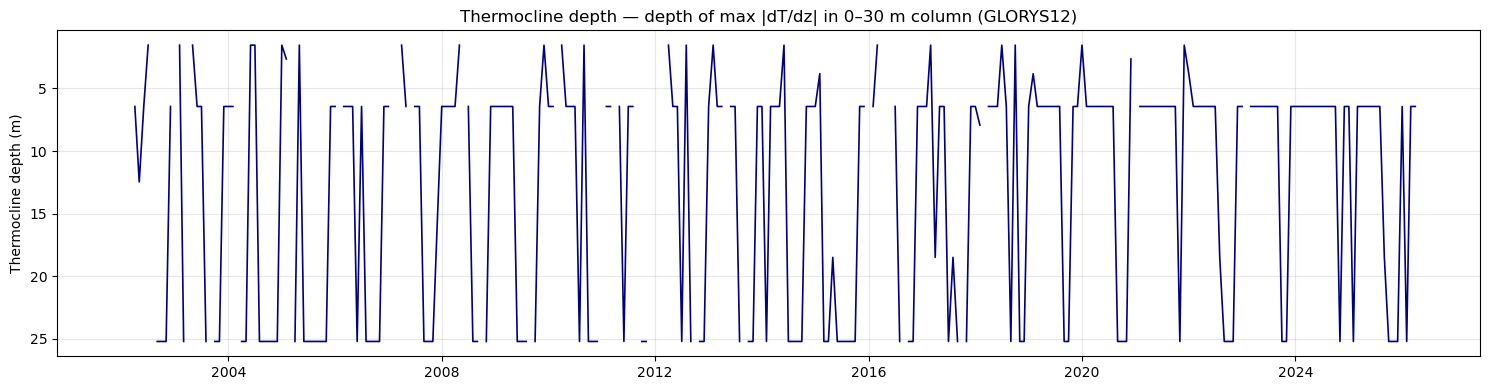

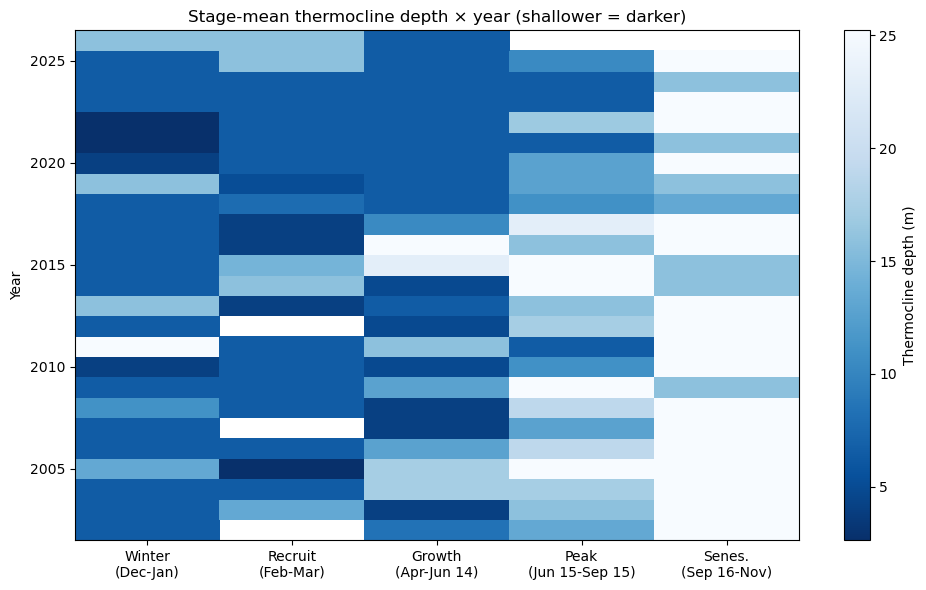

Thermocline depth: mean=12.7 m  std=9.4 m  range=[1.5, 25.2] m
  Mixed-layer months (no thermocline detected): 32 of 296
  Shallowest thermocline: 2002-07-01  →  1.5 m
  Deepest thermocline:    2002-09-01  →  25.2 m


In [19]:
_has_depth = ('depth' in ds_glorys['thetao'].dims and ds_glorys['thetao'].sizes['depth'] >= 2)

if not _has_depth:
    print('GLORYS thetao has <2 depth levels — thermocline section skipped.')
else:
    # Spatial mean over lat/lon first → (time, depth)
    _sp_dims  = [d for d in ['latitude', 'longitude'] if d in ds_glorys['thetao'].dims]
    _t_td     = ds_glorys['thetao'].mean(dim=_sp_dims)   # (time, depth)
    _depths   = _t_td.depth.values.astype(float)
    _dz       = np.diff(_depths)                         # layer thicknesses
    _dT       = np.diff(_t_td.values, axis=1)            # (time, depth-1)
    _dTdz     = np.abs(_dT / _dz[np.newaxis, :])
    _tc_idx   = np.nanargmax(_dTdz, axis=1)
    # When max gradient sits at the top depth level the column is near-isothermal
    # (mixed layer); there is no real thermocline to report.
    _tc_depth = np.where(_tc_idx == 0, np.nan, _depths[_tc_idx])

    _tc_s = pd.Series(_tc_depth, index=pd.DatetimeIndex(_t_td.time.values)).resample('MS').mean()

    # ── 9a. Time series ──────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(_tc_s.index, _tc_s.values, color='navy', lw=1.2)
    ax.invert_yaxis()
    ax.set_ylabel('Thermocline depth (m)')
    ax.set_title('Thermocline depth — depth of max |dT/dz| in 0–30 m column (GLORYS12)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # ── 9b. Stage-mean heatmap ───────────────────────────────────────────────
    _tc_stage = stage_pivot(_tc_s)
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.pcolor([STAGE_LABELS[s] for s in STAGE_ORDER],
                   _tc_stage.index, _tc_stage.values,
                   cmap='Blues_r', shading='auto')
    plt.colorbar(im, ax=ax, label='Thermocline depth (m)')
    ax.set_title('Stage-mean thermocline depth × year (shallower = darker)')
    ax.set_ylabel('Year')
    plt.tight_layout(); plt.show()

    _tc_anom = monthly_anomaly(_tc_s)
    _n_mixed = int(np.isnan(_tc_depth).sum())
    _tc_valid = _tc_s.dropna()
    print(f'Thermocline depth: mean={float(_tc_valid.mean()):.1f} m  '
          f'std={float(_tc_valid.std()):.1f} m  '
          f'range=[{float(_tc_valid.min()):.1f}, {float(_tc_valid.max()):.1f}] m')
    print(f'  Mixed-layer months (no thermocline detected): {_n_mixed} of {len(_tc_depth)}')
    _shallowest = _tc_valid.idxmin()
    _deepest    = _tc_valid.idxmax()
    print(f'  Shallowest thermocline: {str(_shallowest)[:10]}  →  {float(_tc_valid[_shallowest]):.1f} m')
    print(f'  Deepest thermocline:    {str(_deepest)[:10]}  →  {float(_tc_valid[_deepest]):.1f} m')


## Section 10 — Stress-Year Composites

Stage-mean anomaly comparison: stress years (2014, 2022–2025) vs neutral years. Each bar is the mean anomaly across years in that category.

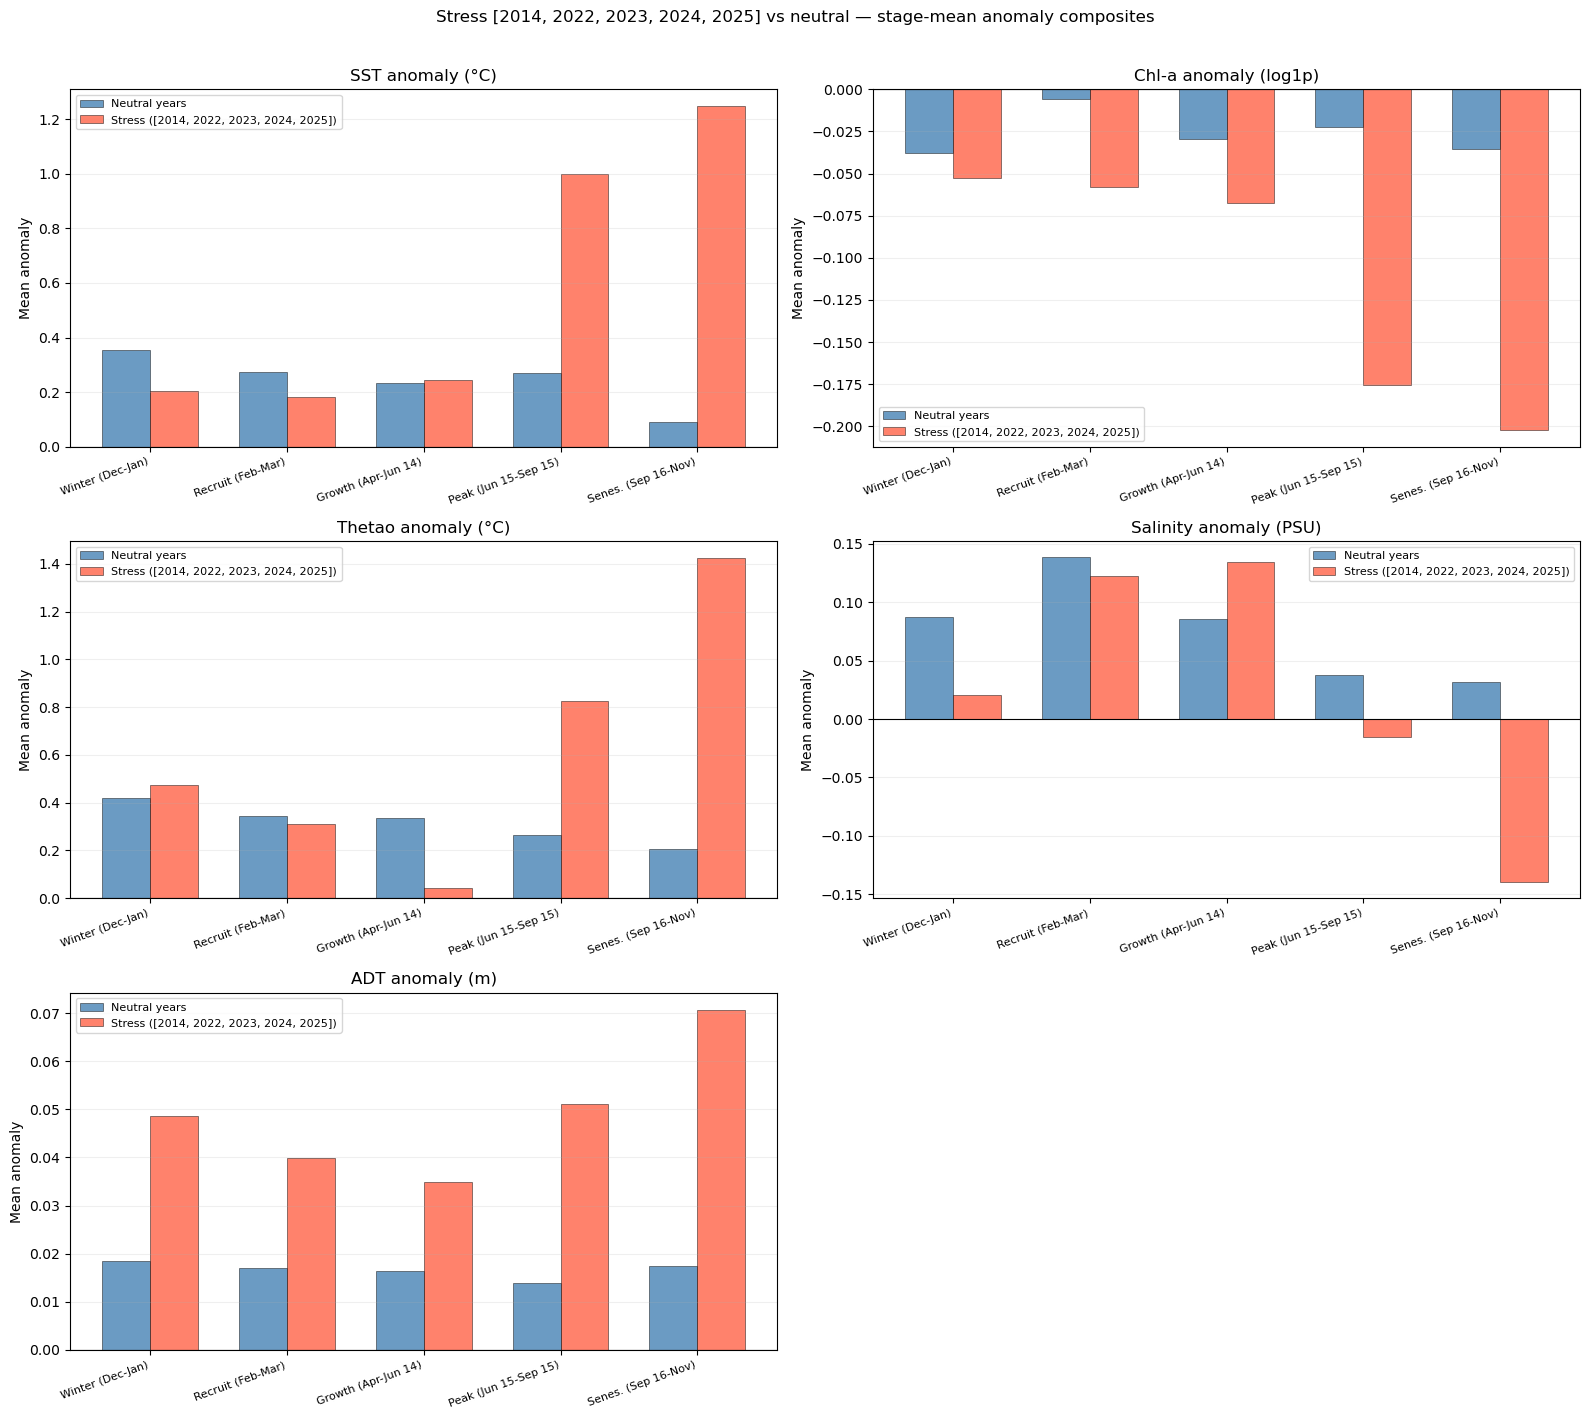

Stress years: [2014, 2022, 2023, 2024, 2025]  (n=5)
Neutral years: n=20
  SST anomaly (°C)             largest stress departure: Senes. (Sep 16-Nov)  (stress +1.248 vs neutral +0.090)
  Chl-a anomaly (log1p)        largest stress departure: Senes. (Sep 16-Nov)  (stress -0.202 vs neutral -0.035)
  Thetao anomaly (°C)          largest stress departure: Senes. (Sep 16-Nov)  (stress +1.424 vs neutral +0.204)
  Salinity anomaly (PSU)       largest stress departure: Senes. (Sep 16-Nov)  (stress -0.139 vs neutral +0.031)
  ADT anomaly (m)              largest stress departure: Senes. (Sep 16-Nov)  (stress +0.071 vs neutral +0.018)


In [20]:
_STRESS_YEARS = [2014, 2022, 2023, 2024, 2025]

def _stage_anomaly_pivot(anom_series):
    """stage_pivot wrapper for anomaly series."""
    return stage_pivot(anom_series)

_sst_stage_anom    = _stage_anomaly_pivot(_sst_anom)
_chla_stage_anom   = _stage_anomaly_pivot(_chla_anom)
_thetao_stage_anom = _stage_anomaly_pivot(_thetao_anom)
_so_stage_anom     = _stage_anomaly_pivot(_so_anom)
_adt_stage_anom    = _stage_anomaly_pivot(_adt_anom)

_all_yrs     = sorted(_sst_stage_anom.index.tolist())
_neutral_yrs = [y for y in _all_yrs if y not in _STRESS_YEARS]

def _composite(df, yrs):
    rows = df.loc[df.index.isin(yrs)]
    return rows.mean()

_var_specs = [
    ('SST anomaly (°C)',        _sst_stage_anom),
    ('Chl-a anomaly (log1p)',   _chla_stage_anom),
    ('Thetao anomaly (°C)',     _thetao_stage_anom),
    ('Salinity anomaly (PSU)',  _so_stage_anom),
    ('ADT anomaly (m)',         _adt_stage_anom),
]

x  = np.arange(len(STAGE_ORDER))
w  = 0.35
_xlbls = [STAGE_LABELS[s].replace('\n', ' ') for s in STAGE_ORDER]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes.flat[-1].set_visible(False)
for ax, (name, df) in zip(axes.flat, _var_specs):
    neu  = _composite(df, _neutral_yrs)
    str_ = _composite(df, _STRESS_YEARS)
    ax.bar(x - w/2, neu.values,  w, label='Neutral years',
           color='steelblue', alpha=0.8, edgecolor='k', linewidth=0.4)
    ax.bar(x + w/2, str_.values, w, label=f'Stress ({_STRESS_YEARS})',
           color='tomato',    alpha=0.8, edgecolor='k', linewidth=0.4)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(_xlbls, rotation=20, ha='right', fontsize=8)
    ax.set_title(name); ax.set_ylabel('Mean anomaly')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2, axis='y')

plt.suptitle(f'Stress {_STRESS_YEARS} vs neutral — stage-mean anomaly composites', y=1.01)
plt.tight_layout(); plt.show()

print(f'Stress years: {_STRESS_YEARS}  (n={len([y for y in _all_yrs if y in _STRESS_YEARS])})')
print(f'Neutral years: n={len(_neutral_yrs)}')
for name, df in _var_specs:
    str_ = _composite(df, _STRESS_YEARS)
    neu_ = _composite(df, _neutral_yrs)
    diff_ = str_ - neu_
    best_i = int(np.nanargmax(np.abs(diff_.values)))
    best_s = STAGE_ORDER[best_i]
    peak   = STAGE_LABELS[best_s].replace("\n", " ")
    print(f'  {name:<28} largest stress departure: {peak}  (stress {float(str_[best_s]):+.3f} vs neutral {float(neu_[best_s]):+.3f})')


## Section 11 — Trend Analysis

Per-stage OLS linear trends for SST, chl-a, subsurface thetao, salinity, and ADT anomalies. Red bars: p < 0.05. Error bars: 95% CI on slope.

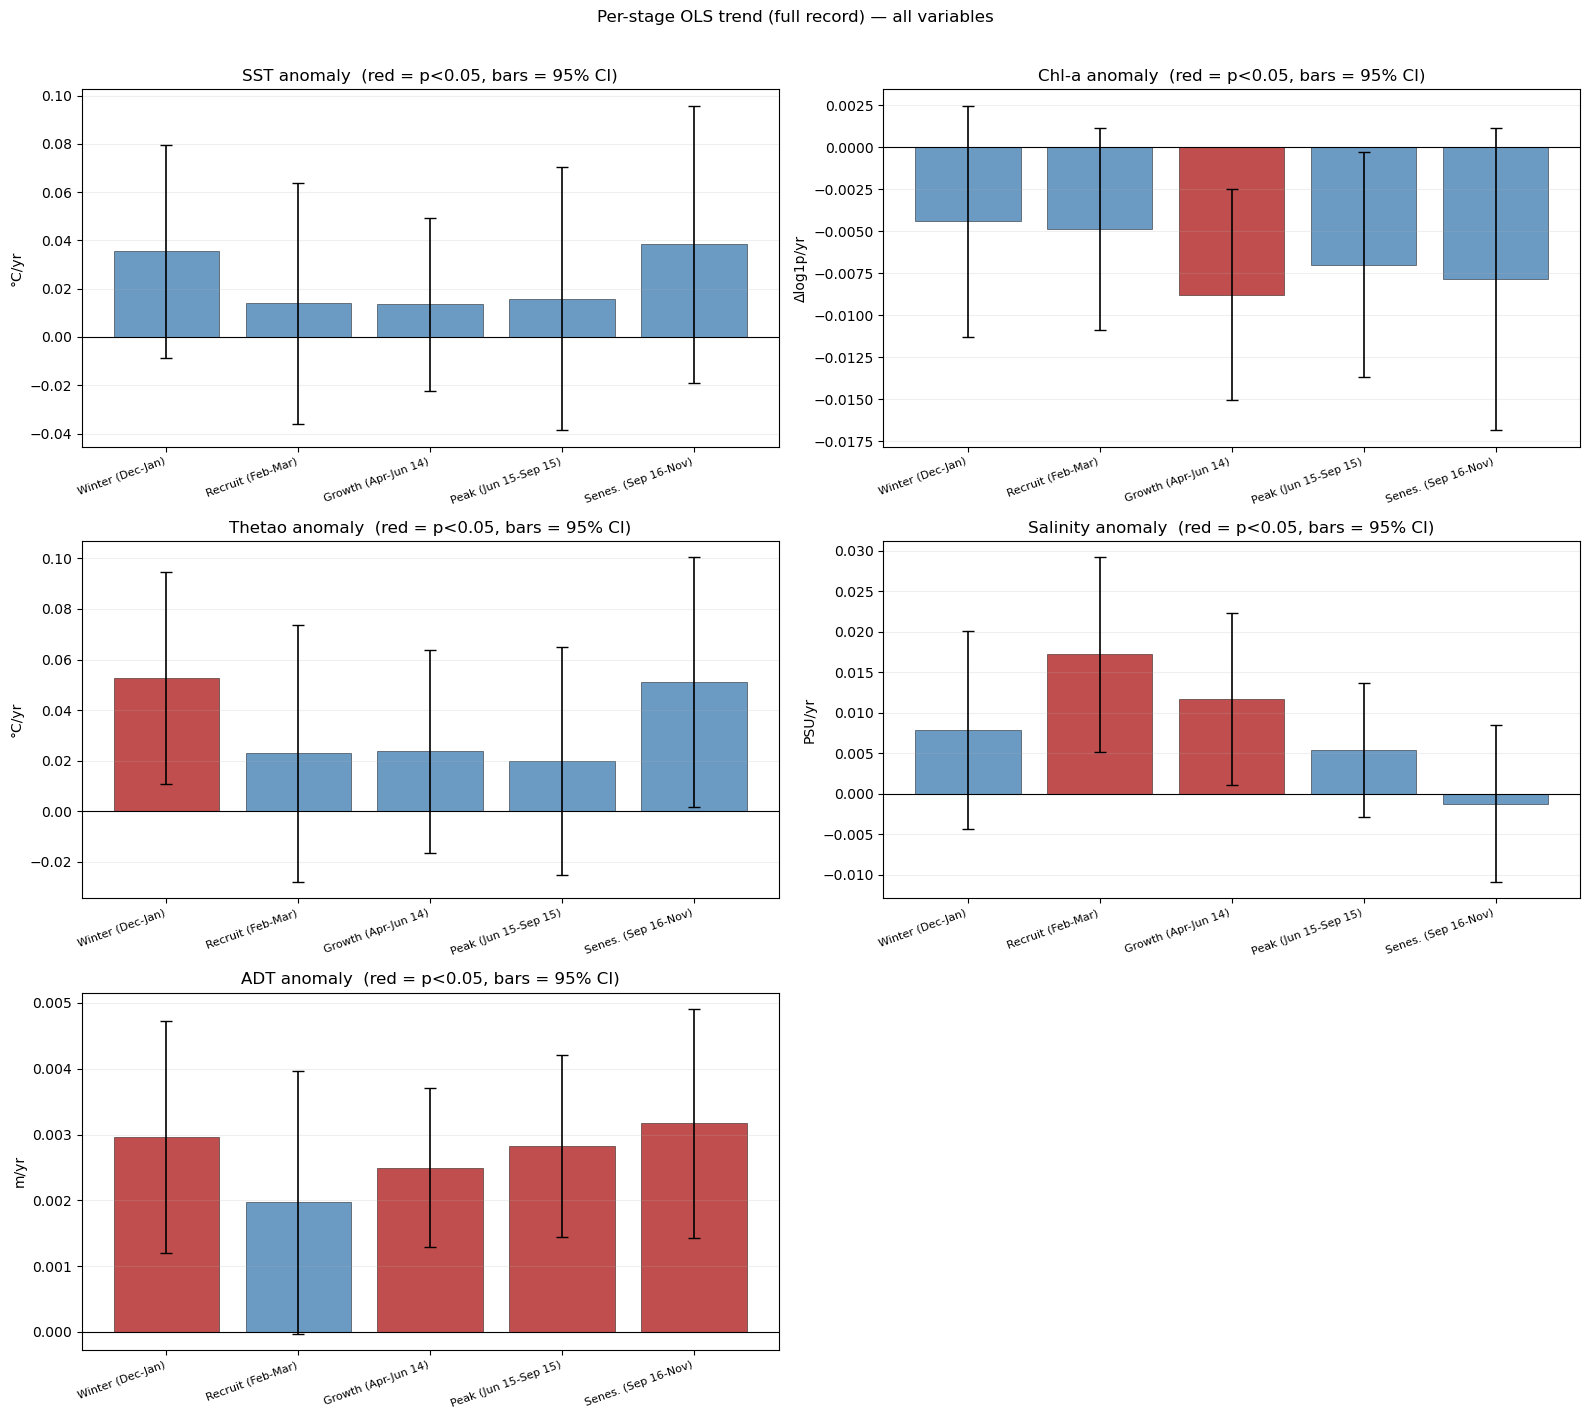

Stage                  SST (°C/yr)       p         Chl-a       p        Thetao       p      Salinity       p           ADT       p
------------------------------------------------------------------------------------------------------------------------
Winter (Dec-Jan)          +0.03559   0.128      -0.00440   0.223      +0.05273   0.022      +0.00786   0.221      +0.00296   0.003
Recruit (Feb-Mar)         +0.01405   0.586      -0.00486   0.126      +0.02292   0.386      +0.01718   0.010      +0.00197   0.066
Growth (Apr-Jun 14)       +0.01352   0.465      -0.00877   0.012      +0.02369   0.261      +0.01167   0.042      +0.00250   0.001
Peak (Jun 15-Sep 15)      +0.01577   0.576      -0.00699   0.054      +0.02005   0.392      +0.00534   0.218      +0.00283   0.001
Senes. (Sep 16-Nov)       +0.03833   0.205      -0.00784   0.102      +0.05100   0.056      -0.00126   0.801      +0.00317   0.002


In [21]:
from scipy import stats as _scipy_stats

def _ols_trends(stage_df):
    slopes, ci95s, pvals = [], [], []
    for s in STAGE_ORDER:
        col = stage_df[s].dropna()
        if len(col) < 5:
            slopes.append(np.nan); ci95s.append(np.nan); pvals.append(np.nan)
            continue
        x = col.index.values.astype(float) - col.index.values.astype(float).min()
        res = _scipy_stats.linregress(x, col.values)
        slopes.append(res.slope)
        ci95s.append(1.96 * res.stderr)
        pvals.append(res.pvalue)
    return np.array(slopes), np.array(ci95s), np.array(pvals)

_sst_sl,  _sst_ci,  _sst_p   = _ols_trends(_sst_stage_anom)
_chl_sl,  _chl_ci,  _chl_p   = _ols_trends(_chla_stage_anom)
_tho_sl,  _tho_ci,  _tho_p   = _ols_trends(_thetao_stage_anom)
_so_sl,   _so_ci,   _so_p    = _ols_trends(_so_stage_anom)
_adt_sl,  _adt_ci,  _adt_p   = _ols_trends(_adt_stage_anom)

_trend_specs = [
    ('SST anomaly',      _sst_sl,  _sst_ci,  _sst_p,  '°C/yr'),
    ('Chl-a anomaly',    _chl_sl,  _chl_ci,  _chl_p,  'Δlog1p/yr'),
    ('Thetao anomaly',   _tho_sl,  _tho_ci,  _tho_p,  '°C/yr'),
    ('Salinity anomaly', _so_sl,   _so_ci,   _so_p,   'PSU/yr'),
    ('ADT anomaly',      _adt_sl,  _adt_ci,  _adt_p,  'm/yr'),
]

x = np.arange(len(STAGE_ORDER))
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes.flat[-1].set_visible(False)
for ax, (title, slopes, ci, pvals, unit) in zip(axes.flat, _trend_specs):
    colors = ['firebrick' if not np.isnan(p) and p < 0.05 else 'steelblue' for p in pvals]
    ax.bar(x, slopes, color=colors, alpha=0.8, edgecolor='k', linewidth=0.4)
    ax.errorbar(x, slopes, yerr=ci, fmt='none', color='k', capsize=4, linewidth=1.2)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(_xlbls, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel(unit); ax.set_title(f'{title}  (red = p<0.05, bars = 95% CI)')
    ax.grid(True, alpha=0.2, axis='y')
plt.suptitle('Per-stage OLS trend (full record) — all variables', y=1.01)
plt.tight_layout(); plt.show()

print(f'{"Stage":<20} {"SST (°C/yr)":>13} {"p":>7} {"Chl-a":>13} {"p":>7} {"Thetao":>13} {"p":>7} {"Salinity":>13} {"p":>7} {"ADT":>13} {"p":>7}')
print('-' * 120)
for i, s in enumerate(STAGE_ORDER):
    lbl = STAGE_LABELS[s].replace("\n", " ")
    print(f'{lbl:<20} {_sst_sl[i]:>+13.5f} {_sst_p[i]:>7.3f} '
          f'{_chl_sl[i]:>+13.5f} {_chl_p[i]:>7.3f} '
          f'{_tho_sl[i]:>+13.5f} {_tho_p[i]:>7.3f} '
          f'{_so_sl[i]:>+13.5f} {_so_p[i]:>7.3f} '
          f'{_adt_sl[i]:>+13.5f} {_adt_p[i]:>7.3f}')


## Section 12 — Summary of Findings

Key results from the CMEMS oceanographic EDA for the Monterey–Mendocino kelp coast (2002–present).

---

### Marine heatwave signal
- The **2014 marine heatwave** dominates the record: SST anomaly peaked at **+4.12 °C** (September 2014), subsurface thetao at **+3.32 °C** simultaneously — confirming the anomaly penetrated into at least the 0–30 m layer, not a skin-only phenomenon. (GLORYS coverage is limited to 30 m; full water-column confirmation requires deeper data.)
- ADT anomaly peaked at **+0.13 m** in October 2015, 13 months after the SST peak. This coincides with the 2015–16 El Niño, which independently drives elevated sea surface height along the California coast via coastal Kelvin waves. Whether this reflects a lagged heatwave response, El Niño forcing, or both cannot be determined from this dataset alone.

### Chlorophyll-a
- Chl-a maximum anomaly was **−0.43 log1p** in October 2022 — the 2014–15 heatwave period shows strong negative anomalies, but the single most extreme recorded minimum falls later. Whether this reflects continued ecosystem degradation, a multi-sensor calibration shift in the OC-CCI blend, or a discrete 2022 oceanographic event is unclear.
- Nearshore chl-a runs **2.19× higher** than offshore on average. This reflects a combination of genuine coastal upwelling productivity — the expected dominant signal in this system — and potential CDOM/sediment inflation from river runoff that OC-CCI cannot cleanly separate at 4 km resolution. The two signals cannot be disentangled without in-situ validation. For kelp habitat modelling, nearshore chl-a is the appropriate feature; offshore values represent oligotrophic water outside the productive coastal zone. 21 extreme inland-water pixels (Sacramento Delta, Clear Lake) are excluded via a time-mean threshold mask.

### Correlations
- **ADT → chl-a** is the strongest ecological coupling (r = −0.55): higher sea surface height suppresses upwelling and reduces surface nutrients.
- **SST → chl-a** is effectively zero (r = +0.01) despite the upwelling expectation — at monthly resolution the cold-nutrient signal is masked by seasonal co-variation.
- **SST skin → thetao 0–30 m** correlation is r = +0.967, consistent with a shallow, well-mixed surface layer. Note the 0–30 m layer includes the surface, so some correlation is structural; the small mean SST−thetao offset (0.07 °C) corroborates that mixed-layer depth is typically shallower than 30 m here.
- Lead-lag CCF shows all peak correlations at **lag 0** months — no detectable predictive lead in any pair at monthly temporal resolution.

### Stress-year composite
- Five stress years (2014, 2022, 2023, 2024, 2025) independently show their largest departure from neutral conditions during **Senescence (Sep 16 – Nov)** across all five variables — SST, thetao, ADT, chl-a, and salinity each identify the same stage without cross-variable coordination. The unanimity of physical, chemical, and biological indicators on a single phenological window is the strongest signal in the record: SST +1.25 °C, thetao +1.42 °C, ADT +0.07 m, chl-a −0.20 log1p, salinity −0.14 PSU (vs +0.03 PSU neutral). Late-season warm/stratified/low-nutrient conditions are the dominant stress signature.
- **2025** is the only year on record with three consecutive productive stages (Recruit, Growth, Peak) simultaneously below their within-stage thresholds.

### Trends (OLS, full record)
- **Subsurface thetao** shows significant warming in Winter only (p = 0.022, +0.053 °C/yr). Senescence-stage warming (p = 0.056) falls just below significance after estuarine pixel removal.
- **ADT** is rising significantly in all stages (p < 0.005, +0.002–0.003 m/yr). The mechanism is not established here — candidates include gyre intensification, Pacific-scale sea level rise, and PDO phase.
- **SST** surface trends are not significant in any stage after anomaly removal (all p > 0.12).
- **Salinity** shows significant rising trends during Recruit (Feb–Mar; p = 0.010, +0.017 PSU/yr) and Growth (Apr–Jun; p = 0.042, +0.012 PSU/yr) stages after estuarine pixel removal — consistent with a long-term reduction in spring/summer freshwater input or a shift in upwelling timing. Other stages are not significant (see Section 11 output table).
- **Chl-a** shows a significant declining trend during Growth (p = 0.012, −0.009 log1p/yr), suggesting long-term productivity loss independent of individual heatwave events. Peak-stage decline (p = 0.054) is not significant after inland-water pixel removal.

### Thermocline
- Mean thermocline depth is **12.7 m ± 9.4 m**; 32 of 296 months are flagged as mixed-layer (no thermocline detected).
- Thermocline is shallowest in late summer (upwelling-driven) and deepest in autumn when stratification breaks down.

### Domain note
- Record SST of **28.31 °C** at 39.125°N, −122.875°E is a Sacramento Delta / Suisun Bay inland-water pixel. All time-series means (SST, thetao, salinity) and spatial analyses are computed with lon < −123° applied to exclude estuarine contamination. GLORYS Sacramento Delta pixels reach 9.7 PSU minimum salinity.

### Data quality
- All four CMEMS products pass seam validation post-correction. ADT NRT bias (+0.013 m) corrected in notebook. GLORYS thetao carries an elevated RMSE (0.94 °C) across the MY→NFC seam due to reanalysis vs. forecast variability mismatch — avoid synoptic subsurface features near 2024-01-01.

In [22]:
# Section 12 — digest table
import pandas as pd

_findings = [
    ('Max SST anomaly',          '2014-09', '+4.12 °C',         'Anomaly into 0–30 m layer; full depth unconfirmed'),
    ('Max thetao anomaly',        '2014-09', '+3.32 °C',         'Penetrated ≥0–30 m; not skin-only'),
    ('Max chl-a anomaly',         '2022-10', '−0.43 log1p',      'Peak stress lagged heatwave by years'),
    ('Max ADT anomaly',           '2015-10', '+0.13 m',          'Coincides with El Niño 2015–16; cause unclear'),
    ('Strongest correlation',     'all time', 'ADT→chl-a r=−0.55','Upwelling suppression signal'),
    ('SST→chl-a correlation',     'all time', 'r=+0.01',          'Seasonally masked at monthly grain'),
    ('Stress stage',              '2014–2025','Senescence',        'Largest departure in all 5 variables'),
    ('ADT trend (Growth)',        'full record','+0.0025 m/yr p=0.001','Mechanism unclear: gyre / PDO / sea level rise'),
    ('Chl-a trend (Growth)',      'full record','−0.009 log1p/yr p=0.012','Significant productivity decline'),
    ('Thetao trend (Winter)',     'full record','+0.053 °C/yr p=0.022','Significant subsurface warming — Winter only'),
    ('Nearshore/offshore ratio',  'climatology','2.19×',           'Upwelling gradient + potential sediment; not separable'),
    ('Domain outlier',            'record max','28.31 °C at −122.9°','Delta pixel; clip lon < −123°'),
]

df_summary = pd.DataFrame(_findings, columns=['Finding', 'Period', 'Value', 'Interpretation'])
print(df_summary.to_string(index=False))


                 Finding      Period                   Value                                         Interpretation
         Max SST anomaly     2014-09                +4.12 °C      Anomaly into 0–30 m layer; full depth unconfirmed
      Max thetao anomaly     2014-09                +3.32 °C                      Penetrated ≥0–30 m; not skin-only
       Max chl-a anomaly     2022-10             −0.43 log1p                   Peak stress lagged heatwave by years
         Max ADT anomaly     2015-10                 +0.13 m          Coincides with El Niño 2015–16; cause unclear
   Strongest correlation    all time       ADT→chl-a r=−0.55                           Upwelling suppression signal
   SST→chl-a correlation    all time                 r=+0.01                     Seasonally masked at monthly grain
            Stress stage   2014–2025              Senescence                   Largest departure in all 5 variables
      ADT trend (Growth) full record    +0.0025 m/yr p=0.001         Mec